In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
import sys

In [3]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

In [4]:
font_files = ["font_type/Times New Roman.ttf", "font_type/Times New Roman Bold.ttf", 
              "font_type/Times New Roman Italic.ttf", "font_type/Times New Roman Bold Italic.ttf"]

for font_file in font_files:
    if os.path.exists(font_file):
        fm.fontManager.addfont(font_file)
        
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

In [5]:
def convert_model_name(model_path):
    """
    Convert full model path to concise label
    Examples:
        'Qwen/Qwen2.5-3B-Instruct' -> 'Q2.5-3B'
        'meta-llama/Llama-3.2-3B-Instruct' -> 'L3.2-3B'
        'mistralai/Mistral-Small-24B-Instruct-2501' -> 'M-24B'
        'google/gemma-2-27b-it' -> 'G2-27B'
        'gpt-4o' -> 'GPT-4o'
    """
    # Get the model name part (after the /)
    if '/' in model_path:
        model_name = model_path.split('/')[-1]
    else:
        model_name = model_path
    
    # Handle GPT models - preserve as is
    if 'gpt' in model_name.lower():
        return model_name
    
    # Extract size (look for patterns like 3B, 70B, etc.)
    import re
    size_match = re.search(r'(\d+(?:\.\d+)?)[bB]', model_name, re.IGNORECASE)
    size = f"-{size_match.group(0).upper()}" if size_match else ""
    
    # Apply family-specific conversions
    if 'Qwen2.5' in model_name:
        return f"Q2.5{size}"
    elif 'Qwen3' in model_name:
        version_match = re.search(r'Qwen3-(\d+)', model_name)
        return f"Q3{size}"
    elif 'Llama-3.3' in model_name:
        return f"L{size}"
    elif 'Llama-3.2' in model_name:
        return f"L{size}"
    elif 'Llama-3.1' in model_name:
        return f"L{size}"
    elif 'Llama' in model_name:
        return f"L{size}"
    elif 'gemma-2' in model_name.lower() or 'gemma2' in model_name.lower():
        return f"G2{size}"
    elif 'Ministral' in model_name:
        return f"M{size}"
    elif 'Mistral-Small' in model_name:
        return f"M{size}"
    elif 'Mistral' in model_name or 'mistral' in model_name:
        return f"M{size}"
    else:
        # For unknown models, try to shorten intelligently
        return model_name.replace('-Instruct', '').replace('-Turbo', '')


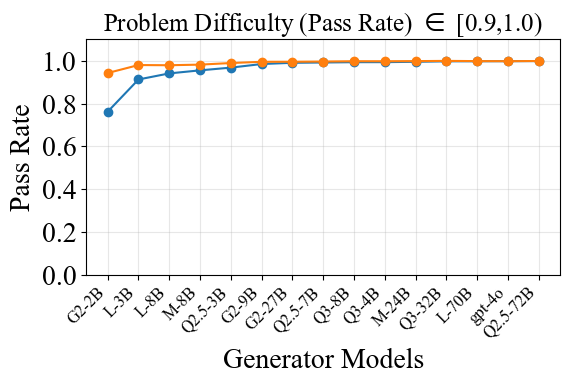

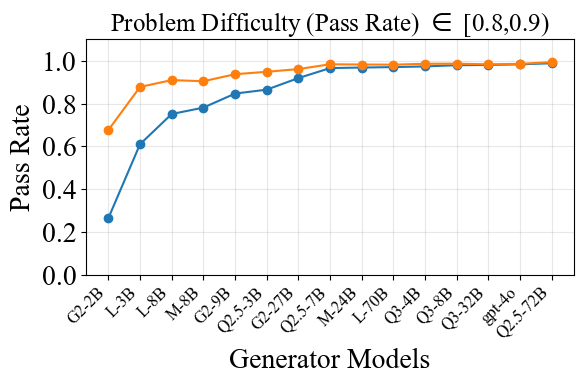

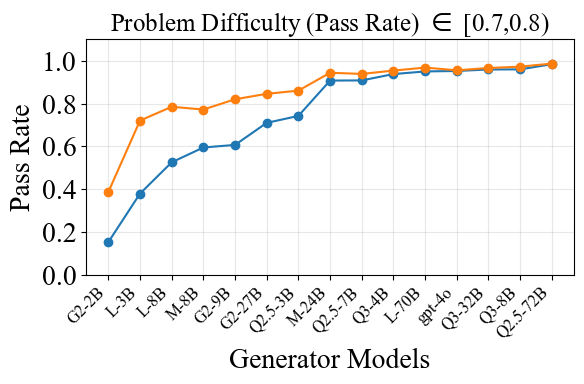

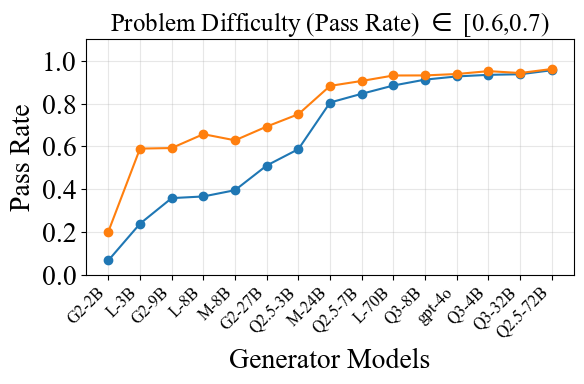

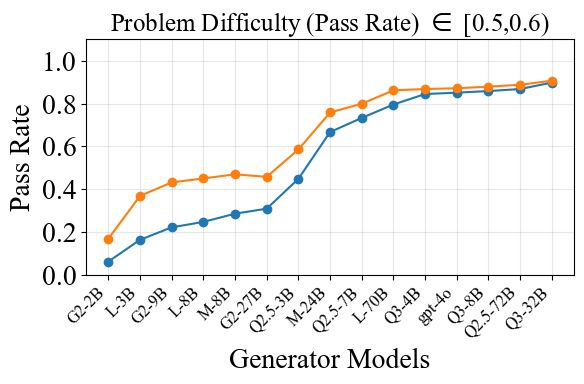

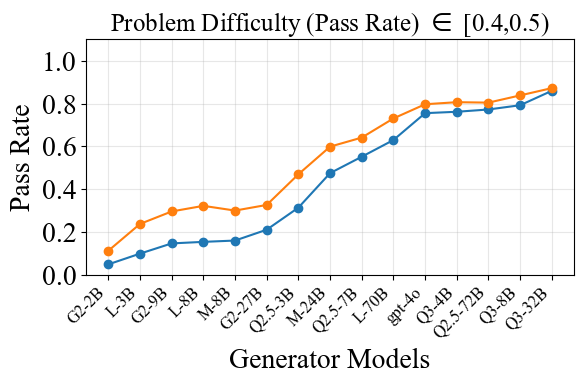

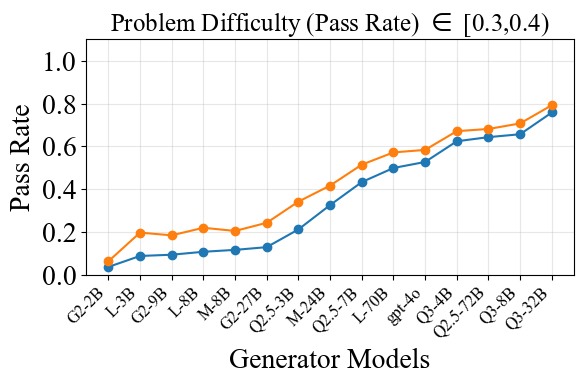

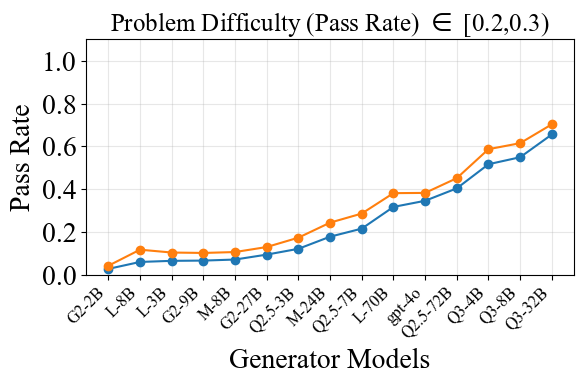

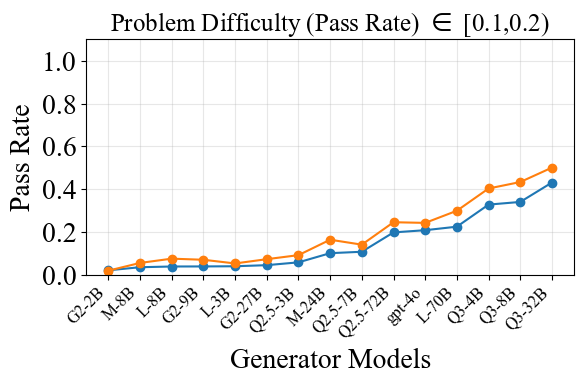

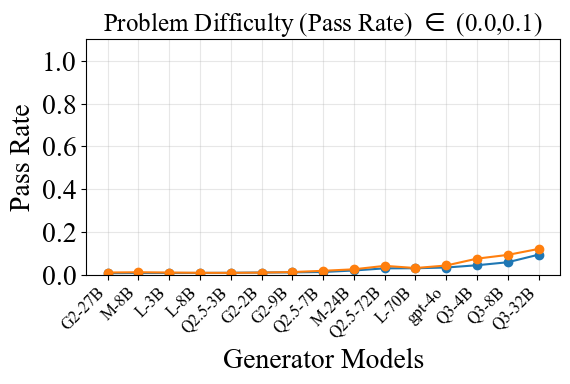

In [ ]:
verifier = 'gpt-4o'
bin_model_key = 'mean'
bin_src_folder='results_correct'
mean_value = np.load(f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1/bin_generator_diff_lst_binmodel_{bin_model_key}.npy', allow_pickle=True).item()

gen_src_path = f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1'
considered_model_lst = [
    'google/gemma-2-2b-it',
    'meta-llama/Llama-3.2-3B-Instruct', 
    'meta-llama/Llama-3.1-8B-Instruct',
    'google/gemma-2-9b-it',
    'mistralai/Ministral-8B-Instruct-2410',  
    'google/gemma-2-27b-it',
    'Qwen/Qwen2.5-3B-Instruct', 
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct',
    'mistralai/Mistral-Small-24B-Instruct-2501', 
    'meta-llama/Llama-3.3-70B-Instruct',
    'Qwen/Qwen3-4B', 
    'Qwen/Qwen3-8B', 
    'Qwen/Qwen3-32B',
    'gpt-4o',
]
for bins in ['[0.9,1.0)', 
             '[0.8,0.9)',
             '[0.7,0.8)',
             '[0.6,0.7)',
             '[0.5,0.6)',
             '[0.4,0.5)',
             '[0.3,0.4)',
             '[0.2,0.3)',
             '[0.1,0.2)',
             '(0.0,0.1)',
             ]:
    all_data = {'original':[], 'after_filter':[]}
    model_names = []

    model_means = []
    for model_key in considered_model_lst:
        #print('mean_value[bins][model_key]',bins, model_key,  mean_value[bins][model_key])
        mean_val = np.mean(mean_value[bins][model_key])
        model_means.append((model_key, mean_val))
        
    model_means_sorted = sorted(model_means, key=lambda x: x[1])
    #for key, value in model_means_sorted:
    #    print(key, value)
    # Extract just the model names as a list
    model_lst = [model_key for model_key, mean_val in model_means_sorted if model_key in considered_model_lst]

    for model in model_lst:
        try:
            # Convert model name to filename format (replace / with _)
            model_filename = model.replace('/', '_').replace('-', '_')
            
            # Load the gene_score file for this model
            gene_score = np.load(f"{gen_src_path}/gene_score_{model_filename}.npy", 
                            allow_pickle=True).item()
            
            #print(gene_score['[0.9,1.0)'][0].keys())
            #sys.exit(0)
            # Extract the average scores for the [0.8,0.9) bin
            if bins in gene_score:
                # Extract scores and filter out NaN values
                scores = [item['average_original'] for item in gene_score[bins]]
                scores_filtered = scores #[s for s in scores if not np.isnan(s)]
                
                after_scores = [item['average'] for item in gene_score[bins]]
                after_scores_filtered = [s for s in after_scores if not np.isnan(s)]
                
                length = len(after_scores_filtered)
                
                if scores_filtered:  # Only add if we have non-NaN values
                    #print('scores_filtered', scores_filtered)
                    all_data['original'].append(scores_filtered)
                    all_data['after_filter'].append(after_scores_filtered)
                    model_names.append(convert_model_name(model))  # Use just the model name part
                    #print(f"{model}: {len(scores)} total samples, {len(scores_filtered)} valid samples, {len(scores) - len(scores_filtered)} NaN values filtered")
                else:
                    print(f"All scores are NaN for {model}")
            else:
                print(f"No [0.8,0.9) bin found for {model}")
                
        except FileNotFoundError:
            print(f"File not found for model: {model}")
        except Exception as e:
            print(f"Error loading {model}: {e}")

    # Check if we have any valid data
    if not all_data['original']:
        print("No valid data found for any models!")
    else:
        # Create the box plot
        n_models = len(all_data['original'])
    
        # Create positions for boxes
        positions_original = np.arange(1, n_models * 3, 3)  # 1, 4, 7, 10, ...
        positions_after = np.arange(1, n_models * 3, 3)    # 2, 5, 8, 11, ...
        
        plt.figure(figsize=(6, 4))
        
        # Create box plots for original data
       # print(np.array(all_data['original']).shape)
        plt.plot(positions_original, 
                 [np.mean(item) for item in all_data['original']], marker='o',
                 label='Before Verification')
        
        plt.plot(positions_after, 
                 [np.mean(item) for item in all_data['after_filter']], marker='o',
                 label='After Verification')

        
        # Set x-axis labels
        tick_positions = (positions_original + positions_after) / 2  # Center between pairs
        plt.xticks(tick_positions, model_names, rotation=45, ha='right')

        # Customize the plot
        plt.xlabel('Generator Models', fontsize=20)
        plt.ylabel('Pass Rate', fontsize=20)
        #plt.title(f'Problem difficulty pass rate {bins} Problem counts: {length}', fontsize=14)
        plt.title(rf'Problem Difficulty (Pass Rate) $\in$ {bins}', fontsize=18)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(fontsize=20)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.ylim([0, 1.1])
        # Show the plot
        #plt.show()
        save_path = f'./figures_draft/tts_subsample_reject_dice/before_after_veri_pass_rate_{bins}_count{length}.pdf'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                  facecolor='white', edgecolor='none')
        
        plt.show()


before filter [(0.15331491712707182, 'G2-2B'), (0.37992058011049723, 'L-3B'), (0.5259841160220995, 'L-8B'), (0.5952175414364641, 'M-8B'), (0.6072168508287292, 'G2-9B'), (0.710203729281768, 'G2-27B'), (0.7425759668508287, 'Q2.5-3B'), (0.9075448895027625, 'M-24B'), (0.908235497237569, 'Q2.5-7B'), (0.9378453038674033, 'Q3-4B'), (0.950103591160221, 'L-70B'), (0.9522617403314917, 'gpt-4o'), (0.9592541436464088, 'Q3-32B'), (0.9597720994475138, 'Q3-8B'), (0.9841160220994475, 'Q2.5-72B')]
after filter [(0.38711258292486683, 'G2-2B'), (0.7207452336868444, 'L-3B'), (0.7852031717116722, 'L-8B'), (0.772280804196768, 'M-8B'), (0.8202317734678025, 'G2-9B'), (0.845696968384354, 'G2-27B'), (0.8605239034874352, 'Q2.5-3B'), (0.9441038687850929, 'M-24B'), (0.9385978372396873, 'Q2.5-7B'), (0.9541410804703211, 'Q3-4B'), (0.9680858635130786, 'L-70B'), (0.9554889491995948, 'gpt-4o'), (0.9662710000438666, 'Q3-32B'), (0.9724304089347079, 'Q3-8B'), (0.9868246015908838, 'Q2.5-72B')]


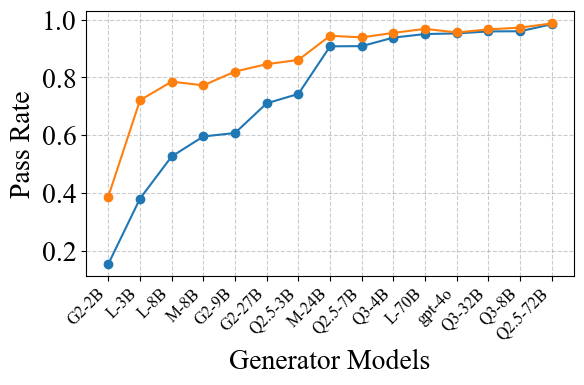

before filter [(0.06796239837398374, 'G2-2B'), (0.23945630081300814, 'L-3B'), (0.3588668699186992, 'G2-9B'), (0.3666158536585366, 'L-8B'), (0.3959603658536585, 'M-8B'), (0.5110518292682927, 'G2-27B'), (0.587525406504065, 'Q2.5-3B'), (0.8051321138211383, 'M-24B'), (0.8459095528455285, 'Q2.5-7B'), (0.8845274390243902, 'L-70B'), (0.9119664634146342, 'Q3-8B'), (0.926829268292683, 'gpt-4o'), (0.9343241869918699, 'Q3-4B'), (0.9369918699186992, 'Q3-32B'), (0.9557926829268293, 'Q2.5-72B')]
after filter [(0.20221429144303468, 'G2-2B'), (0.5899781816006419, 'L-3B'), (0.5926063576349017, 'G2-9B'), (0.6573801804563919, 'L-8B'), (0.6286317887427327, 'M-8B'), (0.6928704224818945, 'G2-27B'), (0.7505785072456823, 'Q2.5-3B'), (0.882769096284293, 'M-24B'), (0.9057852891703764, 'Q2.5-7B'), (0.9312227859241407, 'L-70B'), (0.9315569344948922, 'Q3-8B'), (0.9381795043252005, 'gpt-4o'), (0.9515774311644839, 'Q3-4B'), (0.9427551353723567, 'Q3-32B'), (0.9616018451436472, 'Q2.5-72B')]


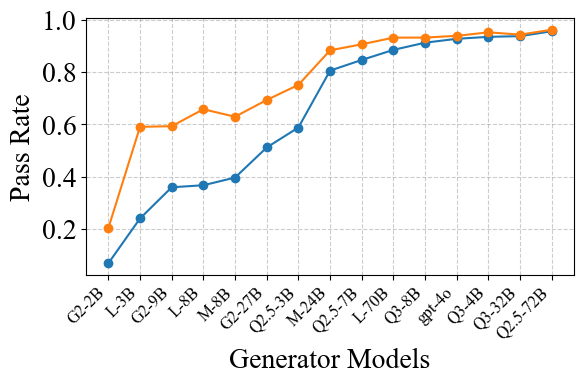

before filter [(0.0625, 'G2-2B'), (0.1642594537815126, 'L-3B'), (0.22229516806722688, 'G2-9B'), (0.24789915966386555, 'L-8B'), (0.2862394957983193, 'M-8B'), (0.30961134453781514, 'G2-27B'), (0.4486607142857143, 'Q2.5-3B'), (0.6672794117647058, 'M-24B'), (0.7331932773109243, 'Q2.5-7B'), (0.7956932773109243, 'L-70B'), (0.8448004201680672, 'Q3-4B'), (0.8509716386554622, 'gpt-4o'), (0.8585871848739496, 'Q3-8B'), (0.8680409663865546, 'Q2.5-72B'), (0.8982405462184874, 'Q3-32B')]
after filter [(0.16910669000349907, 'G2-2B'), (0.3691575270404899, 'L-3B'), (0.43226914192242955, 'G2-9B'), (0.4507215808501698, 'L-8B'), (0.46989502894985197, 'M-8B'), (0.45821878453288234, 'G2-27B'), (0.5858580053113952, 'Q2.5-3B'), (0.758693218636747, 'M-24B'), (0.7996100476609139, 'Q2.5-7B'), (0.8618715040522171, 'L-70B'), (0.8681378005915169, 'Q3-4B'), (0.8716735767083988, 'gpt-4o'), (0.8791310720766157, 'Q3-8B'), (0.8880077799972664, 'Q2.5-72B'), (0.9068330274929044, 'Q3-32B')]


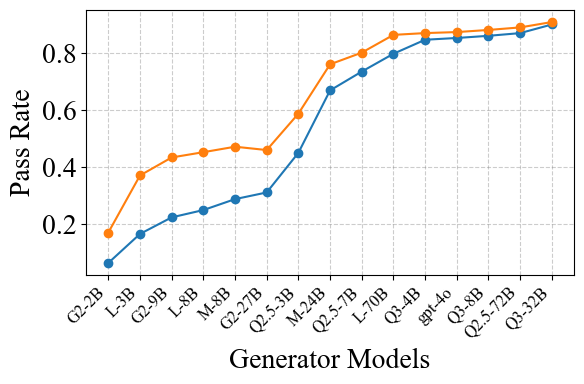

before filter [(0.049639423076923074, 'G2-2B'), (0.09975961538461539, 'L-3B'), (0.14747596153846154, 'G2-9B'), (0.1546875, 'L-8B'), (0.1608173076923077, 'M-8B'), (0.21141826923076923, 'G2-27B'), (0.3144230769230769, 'Q2.5-3B'), (0.4754807692307692, 'M-24B'), (0.5520432692307692, 'Q2.5-7B'), (0.630048076923077, 'L-70B'), (0.7554086538461539, 'gpt-4o'), (0.7618990384615385, 'Q3-4B'), (0.7725961538461539, 'Q2.5-72B'), (0.7924278846153846, 'Q3-8B'), (0.8597355769230769, 'Q3-32B')]
after filter [(0.11317605621478988, 'G2-2B'), (0.23839223871985246, 'L-3B'), (0.29663332435670703, 'G2-9B'), (0.3227709297966044, 'L-8B'), (0.3007160889354958, 'M-8B'), (0.32705938290582404, 'G2-27B'), (0.47018429187495486, 'Q2.5-3B'), (0.599120168077438, 'M-24B'), (0.6413892474625154, 'Q2.5-7B'), (0.7308172364995265, 'L-70B'), (0.7970014242275781, 'gpt-4o'), (0.8065984693589331, 'Q3-4B'), (0.8046263132760402, 'Q2.5-72B'), (0.8382887487205599, 'Q3-8B'), (0.8723660031397587, 'Q3-32B')]


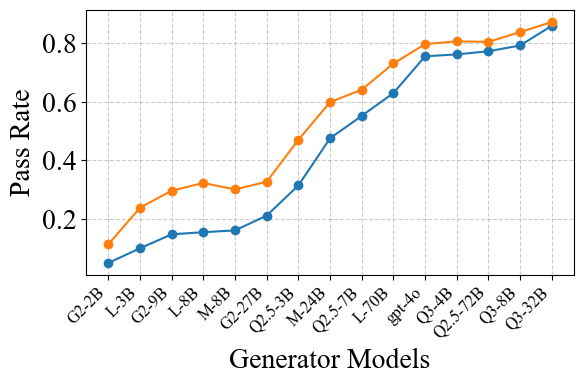

In [ ]:
verifier = 'gpt-4o'
bin_model_key = 'mean'
bin_src_folder='results_correct'
mean_value = np.load(f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1/bin_generator_diff_lst_binmodel_{bin_model_key}.npy', allow_pickle=True).item()

gen_src_path = f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1'
considered_model_lst = [
    'google/gemma-2-2b-it',
    'meta-llama/Llama-3.2-3B-Instruct', 
    'meta-llama/Llama-3.1-8B-Instruct',
    'google/gemma-2-9b-it',
    'mistralai/Ministral-8B-Instruct-2410',  
    'google/gemma-2-27b-it',
    'Qwen/Qwen2.5-3B-Instruct', 
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct',
    'mistralai/Mistral-Small-24B-Instruct-2501', 
    'meta-llama/Llama-3.3-70B-Instruct',
    'Qwen/Qwen3-4B', 
    'Qwen/Qwen3-8B', 
    'Qwen/Qwen3-32B',
    'gpt-4o',
]

for bins in [
            '[0.7,0.8)',
            '[0.6,0.7)',
             '[0.5,0.6)',
             '[0.4,0.5)',
             ]:
    all_data = {'original':[], 'after_filter':[]}
    model_names = []

    model_means = []
    for model_key in considered_model_lst:
        #print('mean_value[bins][model_key]',bins, model_key,  mean_value[bins][model_key])
        mean_val = np.mean(mean_value[bins][model_key])
        model_means.append((model_key, mean_val))
        
    model_means_sorted = sorted(model_means, key=lambda x: x[1])
    #for key, value in model_means_sorted:
    #    print(key, value)
    # Extract just the model names as a list
    model_lst = [model_key for model_key, mean_val in model_means_sorted if model_key in considered_model_lst]

    for model in model_lst:
        try:
            # Convert model name to filename format (replace / with _)
            model_filename = model.replace('/', '_').replace('-', '_')
            
            # Load the gene_score file for this model
            gene_score = np.load(f"{gen_src_path}/gene_score_{model_filename}.npy", 
                            allow_pickle=True).item()
            
            # Extract the average scores for the [0.8,0.9) bin
            if bins in gene_score:
                # Extract scores and filter out NaN values
                scores = [item['average_original'] for item in gene_score[bins]]
                scores_filtered = scores #[s for s in scores if not np.isnan(s)]
                
                after_scores = [item['average'] for item in gene_score[bins]]
                after_scores_filtered = [s for s in after_scores if not np.isnan(s)]
                
                length = len(after_scores_filtered)
                
                if scores_filtered:  # Only add if we have non-NaN values
                    #print('scores_filtered', scores_filtered)
                    all_data['original'].append(scores_filtered)
                    all_data['after_filter'].append(after_scores_filtered)
                    model_names.append(convert_model_name(model))  # Use just the model name part
                    #print(f"{model}: {len(scores)} total samples, {len(scores_filtered)} valid samples, {len(scores) - len(scores_filtered)} NaN values filtered")
                else:
                    print(f"All scores are NaN for {model}")
            else:
                print(f"No [0.8,0.9) bin found for {model}")
                
        except FileNotFoundError:
            print(f"File not found for model: {model}")
        except Exception as e:
            print(f"Error loading {model}: {e}")

    # Check if we have any valid data
    if not all_data['original']:
        print("No valid data found for any models!")
    else:
        # Create the box plot
        
        n_models = len(all_data['original'])
    
        # Create positions for boxes
        positions_original = np.arange(1, n_models * 3, 3)  # 1, 4, 7, 10, ...
        positions_after = np.arange(1, n_models * 3, 3)    # 2, 5, 8, 11, ...
        
        plt.figure(figsize=(6, 4))
        
        # Create box plots for original data
       # print(np.array(all_data['original']).shape)
        plt.plot(positions_original, 
                 [np.mean(item) for item in all_data['original']], marker='o',
                 label='Before Verification')
        
        mean_values_after_f = [np.mean(item) for item in all_data['original']]
        print('before filter', [tuple for tuple in zip(mean_values_after_f, model_names)])
        
        mean_values_after_f = [np.mean(item) for item in all_data['after_filter']]
        print('after filter', [tuple for tuple in zip(mean_values_after_f, model_names)])
        
        
        plt.plot(positions_after, 
                 [np.mean(item) for item in all_data['after_filter']], marker='o',
                 label='After Verification')

        # Set x-axis labels
        tick_positions = (positions_original + positions_after) / 2  # Center between pairs
        plt.xticks(tick_positions, model_names, rotation=45, ha='right')
        


        # Customize the plot
        plt.xlabel('Generator Models', fontsize=20)
        plt.ylabel('Pass Rate', fontsize=20)
        plt.yticks(fontsize=20)
        plt.xticks(rotation=45, ha='right')
        #plt.grid(True, alpha=0.3)
        plt.grid(True, linestyle='--', which='major', color='grey', alpha=.4)
        plt.tight_layout()

        #plt.ylim([-0.5, 1])
        # Show the plot
        #plt.show()
        save_path = f'./figures_draft/tts_subsample_reject_dice/before_after_veri_pass_rate_{bins}_count{length}_wo_title.pdf'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        
        save_path = f'./figures_draft/tts_subsample_reject_dice/before_after_veri_pass_rate_{bins}_count{length}_wo_title.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        
        plt.show()


In [ ]:
verifier = 'gpt-4o'
bin_model_key = 'mean'
bin_src_folder='results_correct'
mean_value = np.load(f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1/bin_generator_diff_lst_binmodel_{bin_model_key}.npy', allow_pickle=True).item()

gen_src_path = f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1'
considered_model_lst = [
    'google/gemma-2-2b-it',
    'meta-llama/Llama-3.2-3B-Instruct', 
    'meta-llama/Llama-3.1-8B-Instruct',
    'google/gemma-2-9b-it',
    'mistralai/Ministral-8B-Instruct-2410',  
    'google/gemma-2-27b-it',
    'Qwen/Qwen2.5-3B-Instruct', 
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct',
    'mistralai/Mistral-Small-24B-Instruct-2501', 
    'meta-llama/Llama-3.3-70B-Instruct',
    'Qwen/Qwen3-4B', 
    'Qwen/Qwen3-8B', 
    'Qwen/Qwen3-32B',
    'gpt-4o',
]
    # 'Qwen/Qwen2.5-14B-Instruct',
    # 'Qwen/Qwen2.5-32B-Instruct',

# Collect data for each model
entire_bin_lst = ['[0.9,1.0)', 
                '[0.8,0.9)',
                '[0.7,0.8)',
                '[0.6,0.7)',
                '[0.5,0.6)',
                '[0.4,0.5)',
                '[0.3,0.4)',
                '[0.2,0.3)',
                '[0.1,0.2)',
                '(0.0,0.1)',
                ]
model_means_dict = {}

for model_key in considered_model_lst:
    model_means_dict[model_key] = []
    for bins in entire_bin_lst:
        model_means_dict[model_key].extend(mean_value[bins][model_key])
        
for key in model_means_dict:
    model_means_dict[key] = np.mean(model_means_dict[key])

model_means = [(key, model_means_dict[key]) for key in model_means_dict]
model_means_sorted = sorted(model_means, key=lambda x: x[1])
# print('model_means_sorted', model_means_sorted)
model_lst = [model_key for model_key, mean_val in model_means_sorted if model_key in considered_model_lst]
print('model_lst', model_lst)

model_orderedby_cap_before_dict = {}
model_orderedby_cap_after_dict = {}
for model in model_lst:
    # Convert model name to filename format (replace / with _)
    model_filename = model.replace('/', '_').replace('-', '_')
    
    # Load the gene_score file for this model
    gene_score = np.load(f"{gen_src_path}/gene_score_{model_filename}.npy", 
                    allow_pickle=True).item()
    
    all_bins_before_score = []
    all_bins_after_score = []
    for bins in entire_bin_lst:
        if bins in gene_score:
            # Extract scores and filter out NaN values
            scores = [item['average_original'] for item in gene_score[bins]]
            scores_filtered = scores #[s for s in scores if not np.isnan(s)]
            for s in scores_filtered:
                assert not np.isnan(s)
            
            all_bins_before_score += scores_filtered
            
            after_scores = [item['average'] for item in gene_score[bins]]
            after_scores_filtered = after_scores #[s for s in after_scores if not np.isnan(s)]
            for s in after_scores_filtered:
                assert not np.isnan(s)
                
            all_bins_after_score += after_scores_filtered
        else:
            raise NotImplementedError
    
    assert len(all_bins_before_score) == 2115
    assert len(all_bins_after_score) == 2115
    model_orderedby_cap_before_dict[model] = all_bins_before_score
    model_orderedby_cap_after_dict[model] = all_bins_after_score

n_models = len(model_lst)
percentage_close_matrix = np.full((n_models, n_models), np.nan)

for i in range(len(model_lst)):
    for j in range(i + 1, len(model_lst)):
        smaller_model, larger_model = model_lst[i], model_lst[j]
        before_gap = np.mean(model_orderedby_cap_before_dict[larger_model]) - np.mean(model_orderedby_cap_before_dict[smaller_model])
        after_gap = np.mean(model_orderedby_cap_after_dict[larger_model]) - np.mean(model_orderedby_cap_after_dict[smaller_model])
        
        if before_gap != 0:
            percentage_close_val = (before_gap - after_gap) / before_gap
        else:
            raise NotImplementedError
        
        percentage_close_matrix[i, j] = percentage_close_val
        


model_lst ['google/gemma-2-2b-it', 'meta-llama/Llama-3.2-3B-Instruct', 'meta-llama/Llama-3.1-8B-Instruct', 'mistralai/Ministral-8B-Instruct-2410', 'google/gemma-2-9b-it', 'google/gemma-2-27b-it', 'Qwen/Qwen2.5-3B-Instruct', 'mistralai/Mistral-Small-24B-Instruct-2501', 'Qwen/Qwen2.5-7B-Instruct', 'meta-llama/Llama-3.3-70B-Instruct-Turbo', 'gpt-4o', 'Qwen/Qwen2.5-72B-Instruct-Turbo', 'Qwen/Qwen3-4B', 'Qwen/Qwen3-8B', 'Qwen/Qwen3-32B']


Data range: [-1.00, 1.00]
Number of values: 105


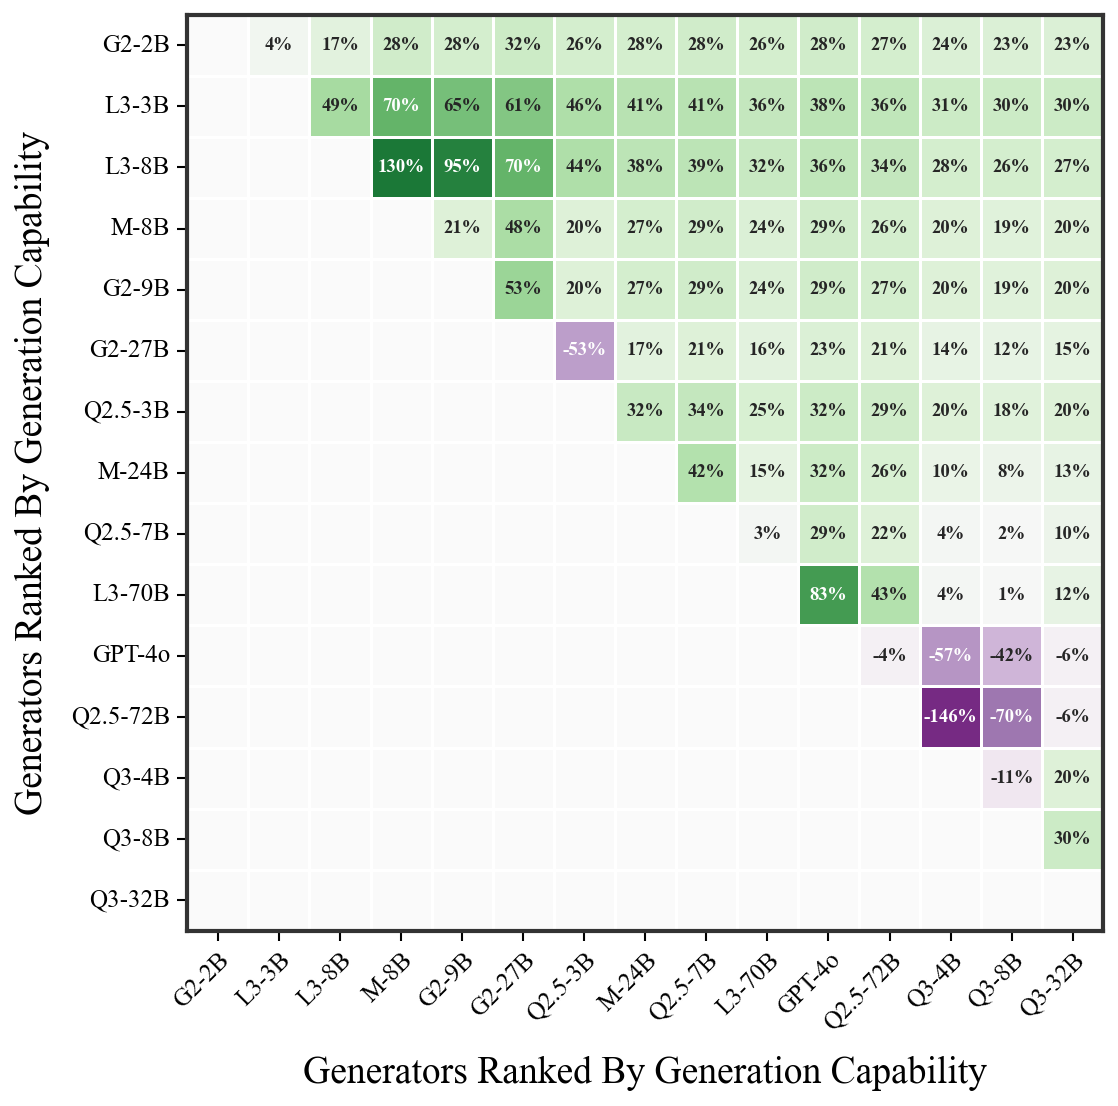

In [ ]:
def convert_model_name(model_path):
    """
    Convert full model path to concise label
    Examples:
        'Qwen/Qwen2.5-3B-Instruct' -> 'Q2.5-3B'
        'meta-llama/Llama-3.2-3B-Instruct' -> 'L3.2-3B'
        'mistralai/Mistral-Small-24B-Instruct-2501' -> 'M-24B'
        'google/gemma-2-27b-it' -> 'G2-27B'
        'gpt-4o' -> 'GPT-4o'
    """
    # Get the model name part (after the /)
    if '/' in model_path:
        model_name = model_path.split('/')[-1]
    else:
        model_name = model_path
    
    # Handle GPT models - preserve as is
    if 'gpt' in model_name.lower():
        return 'GPT-4o'
    
    # Extract size (look for patterns like 3B, 70B, etc.)
    import re
    size_match = re.search(r'(\d+(?:\.\d+)?)[bB]', model_name, re.IGNORECASE)
    size = f"-{size_match.group(0).upper()}" if size_match else ""
    
    # Apply family-specific conversions
    if 'Qwen2.5' in model_name:
        return f"Q2.5{size}"
    elif 'Qwen3' in model_name:
        version_match = re.search(r'Qwen3-(\d+)', model_name)
        return f"Q3{size}"
    elif 'Llama-3.3' in model_name:
        return f"L3{size}"
    elif 'Llama-3.2' in model_name:
        return f"L3{size}"
    elif 'Llama-3.1' in model_name:
        return f"L3{size}"
    elif 'Llama' in model_name:
        return f"L3{size}"
    elif 'gemma-2' in model_name.lower() or 'gemma2' in model_name.lower():
        return f"G2{size}"
    elif 'Ministral' in model_name:
        return f"M{size}"
    elif 'Mistral-Small' in model_name:
        return f"M{size}"
    elif 'Mistral' in model_name or 'mistral' in model_name:
        return f"M{size}"
    else:
        # For unknown models, try to shorten intelligently
        return model_name.replace('-Instruct', '').replace('-Turbo', '')


labels = [convert_model_name(model) for model in model_lst]

# Create DataFrame
df = pd.DataFrame(percentage_close_matrix, index=labels, columns=labels)

# Create mask for LOWER triangle (including diagonal) - we want to show upper triangle
mask = np.tril(np.ones_like(percentage_close_matrix, dtype=bool))

# Get all values in upper triangle for statistics
upper_triangle_values = percentage_close_matrix[np.triu_indices_from(percentage_close_matrix, k=1)]
valid_values = upper_triangle_values[~np.isnan(upper_triangle_values)]

# Use FULL range of data - no exclusions
# vmin = np.min(valid_values)
# vmax = np.max(valid_values)
vmin = -1  # -100%
vmax = 1.0   # 200%

print(f"Data range: [{vmin:.2f}, {vmax:.2f}]")
print(f"Number of values: {len(valid_values)}")

# Set style for publication quality
sns.set_context("paper", font_scale=1.2)

# Create figure with specific DPI for publication
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Create custom colormap with a different color scheme (purple to green through white)
colors = ['#762a83', '#9970ab', '#c2a5cf', '#e7d4e8',
          '#f7f7f7',
          '#d9f0d3', '#a6dba0', '#5aae61', '#1b7837']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_diverging', colors, N=n_bins)


im = sns.heatmap(df, 
            annot=True,
            fmt='.0%',
            cmap=cmap,
            center=0,
            square=True,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            vmin=vmin, 
            vmax=vmax,
            mask=mask,
            cbar=False)
            #cbar=True)

# Set axis labels - note the swap for upper triangle
ax.set_xlabel('Generators Ranked By Generation Capability', fontsize=18, labelpad=10)
ax.set_ylabel('Generators Ranked By Generation Capability', fontsize=18, labelpad=10)

# Improve tick labels
ax.tick_params(axis='x', which='major', labelsize=12, rotation=45)
ax.tick_params(axis='y', which='major', labelsize=12, rotation=0)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Add subtle background
ax.set_facecolor('#fafafa')

# Add border around the entire heatmap
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('#333333')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Save figure in high quality
plt.savefig('figures_draft/tts_subsample_reject_dice/percentage_close_heatmap_upper_triangle.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures_draft/tts_subsample_reject_dice/percentage_close_heatmap_upper_triangle.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()



/tmp/ipykernel_2506897/4154635372.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


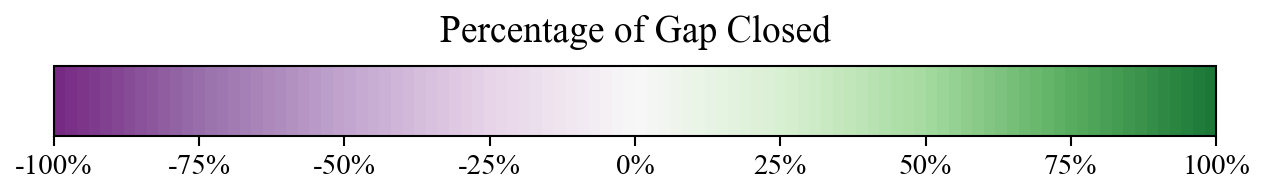

In [96]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Create standalone horizontal colorbar figure
fig, ax = plt.subplots(figsize=(10, 0.6), dpi=150)

# Use the same purple-to-green colormap from your heatmap
colors = ['#762a83', '#9970ab', '#c2a5cf', '#e7d4e8',
          '#f7f7f7',
          '#d9f0d3', '#a6dba0', '#5aae61', '#1b7837']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_diverging', colors, N=n_bins)

# REPLACE THESE WITH YOUR ACTUAL VALUES
# vmin = -1.46  # Replace with your vmin
# vmax = 1.30   # Replace with your vmax

# Create colorbar with the same normalization as your heatmap
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cb = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')

# Set evenly spaced ticks across the actual range
# Calculate reasonable tick positions based on vmin and vmax
num_ticks = 9
tick_positions = np.linspace(-1, 1, num_ticks)
cb.set_ticks(tick_positions)
cb.ax.tick_params(labelsize=14)

# Format tick labels as percentages
tick_labels = [f'{int(t*100)}%' for t in tick_positions]
cb.set_ticklabels(tick_labels)

# Add title
plt.title('Percentage of Gap Closed', fontsize=18, pad=12)

# Remove frame/spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save the colorbar
plt.savefig('figures_draft/tts_subsample_reject_dice/colorbar_horizontal.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figures_draft/tts_subsample_reject_dice/colorbar_horizontal.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

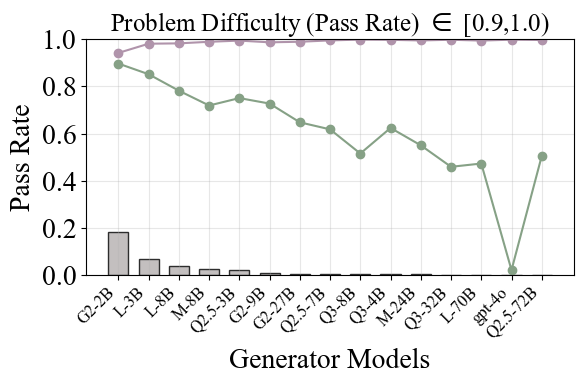

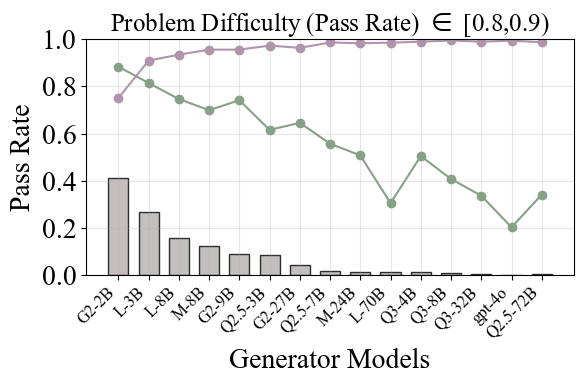

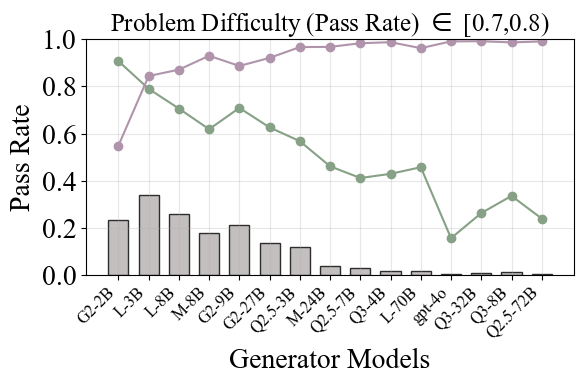

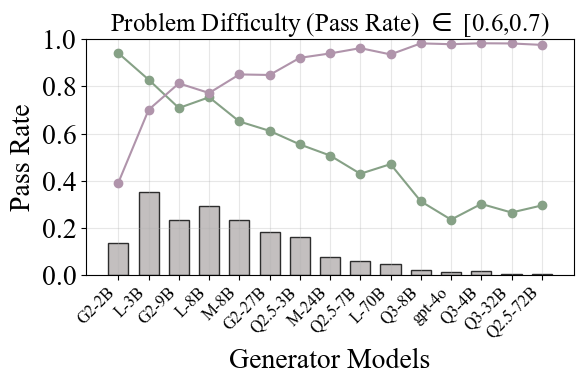

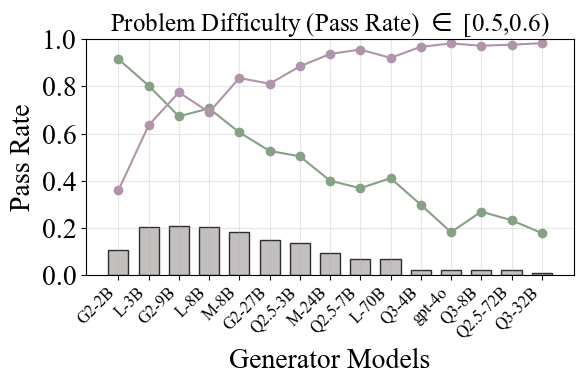

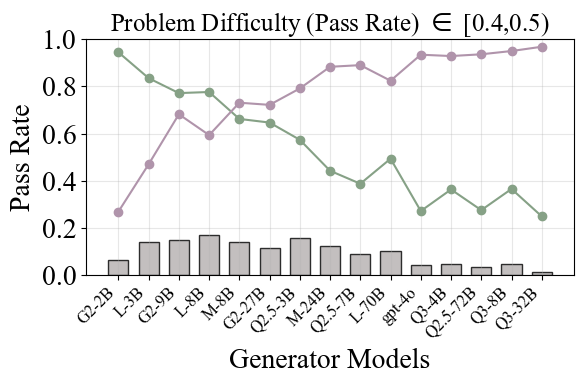

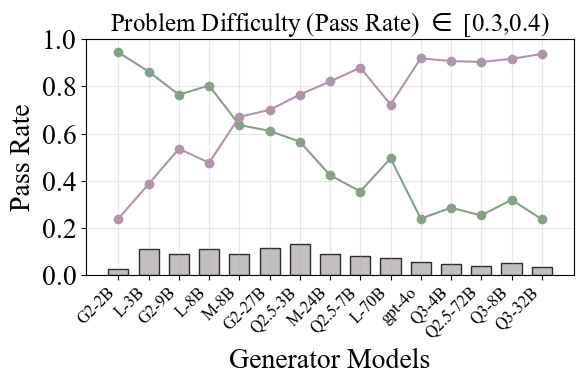

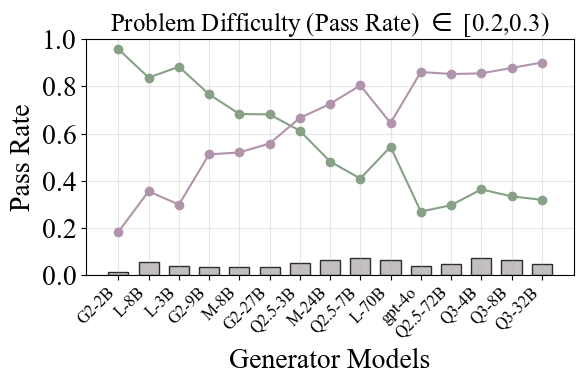

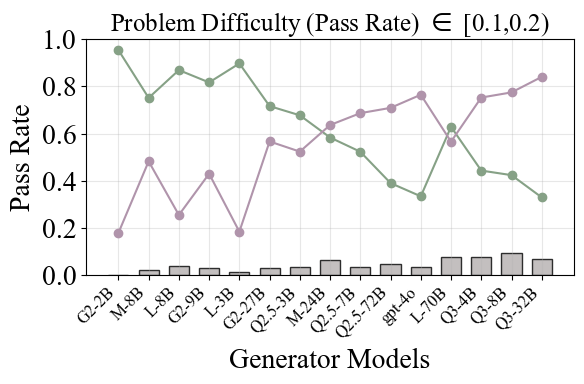

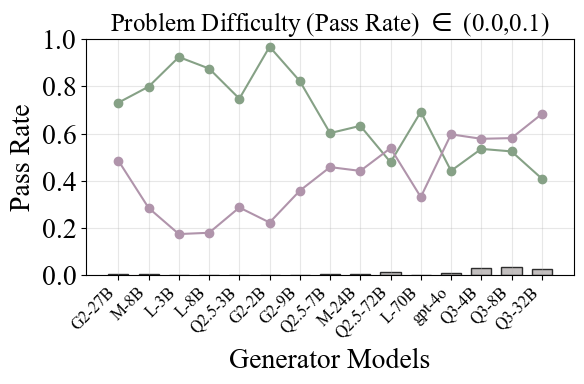

In [ ]:
verifier = 'gpt-4o'
bin_model_key = 'mean'
bin_src_folder='results_correct'
mean_value = np.load(f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1/bin_generator_diff_lst_binmodel_{bin_model_key}.npy', allow_pickle=True).item()

gen_src_path = f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1'
considered_model_lst = [
    'google/gemma-2-2b-it',
    'meta-llama/Llama-3.2-3B-Instruct', 
    'meta-llama/Llama-3.1-8B-Instruct',
    'google/gemma-2-9b-it',
    'mistralai/Ministral-8B-Instruct-2410',  
    'google/gemma-2-27b-it',
    'Qwen/Qwen2.5-3B-Instruct', 
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct',
    'mistralai/Mistral-Small-24B-Instruct-2501', 
    'meta-llama/Llama-3.3-70B-Instruct',
    'Qwen/Qwen3-4B', 
    'Qwen/Qwen3-8B', 
    'Qwen/Qwen3-32B',
    'gpt-4o',
]
    # 'Qwen/Qwen2.5-14B-Instruct',
    # 'Qwen/Qwen2.5-32B-Instruct',

# Collect data for each model

for bins in [
            '[0.9,1.0)', 
             '[0.8,0.9)',
             '[0.7,0.8)',
             '[0.6,0.7)',
            '[0.5,0.6)',
             '[0.4,0.5)',
             '[0.3,0.4)',
             '[0.2,0.3)',
             '[0.1,0.2)',
             '(0.0,0.1)',
             ]:
    all_data = {'original':[], 
                'tnr':[], 'tpr': [], 
                'tnr_agg':[],  
                'tpr_agg': []}
    model_names = []

    model_means = []
    for model_key in considered_model_lst:
        #print('mean_value[bins][model_key]',bins, model_key,  mean_value[bins][model_key])
        mean_val = np.mean(mean_value[bins][model_key])
        model_means.append((model_key, mean_val))
        
    model_means_sorted = sorted(model_means, key=lambda x: x[1])
    #for key, value in model_means_sorted:
    #    print(key, value)
    # Extract just the model names as a list
    model_lst = [model_key for model_key, mean_val in model_means_sorted if model_key in considered_model_lst]

    for model in model_lst:
        try:
            # Convert model name to filename format (replace / with _)
            model_filename = model.replace('/', '_').replace('-', '_')
            
            # Load the gene_score file for this model
            gene_score = np.load(f"{gen_src_path}/gene_score_{model_filename}.npy", 
                            allow_pickle=True).item()
            
            # Extract the average scores for the [0.8,0.9) bin
            if bins in gene_score:
                scores_filtered = []
                scores_tnr_avg = []
                scores_tpr_avg = []
                tnr_agg = 0
                false_agg = 0
                tpr_agg = 0
                true_agg = 0
                for item in gene_score[bins]:
                    if not np.isnan(item['average']) and not np.isnan(item['average_original']):
                        improv = item['average'] - item['average_original']
                        scores_filtered.append(improv)
                    
                    if item['false_count'] > 0:
                        scores_tnr_avg.append(item['true_neg_pred_half'] / item['false_count'])
                        
                    tnr_agg += item['true_neg_pred_half']
                    false_agg += item['false_count']
                    
                    if item['true_count'] > 0:
                        scores_tpr_avg.append(item['true_pos_pred_half'] / item['true_count'])
                    
                    tpr_agg += item['true_pos_pred_half']
                    true_agg += item['true_count']
                
                if scores_filtered:  # Only add if we have non-NaN values
                    #print('scores_filtered', scores_filtered)
                    all_data['original'].append(scores_filtered)
                    all_data['tnr'].append(scores_tnr_avg)
                    all_data['tpr'].append(scores_tpr_avg)

                    #all_data['after_filter'].append(after_scores_filtered)
                    model_names.append(convert_model_name(model))  # Use just the model name part
                    #print(f"{model}: {len(scores)} total samples, {len(scores_filtered)} valid samples, {len(scores) - len(scores_filtered)} NaN values filtered")
                else:
                    print(f"All scores are NaN for {model}")
            else:
                print(f"No [0.8,0.9) bin found for {model}")
                
        except FileNotFoundError:
            print(f"File not found for model: {model}")
        except Exception as e:
            print(f"Error loading {model}: {e}")

    # Check if we have any valid data
    if not all_data['original']:
        print("No valid data found for any models!")
    else:
        # Create the box plot
        
        n_models = len(all_data['original'])
    
        # Create positions for boxes
        positions_original = np.arange(1, n_models * 3, 3)  # 1, 4, 7, 10, ...
        
        plt.figure(figsize=(6, 4))
        positions = np.arange(n_models)

        bar_width = 2
        #print('positions', positions)
        plt.bar(positions_original, 
                 [np.mean(item) for item in all_data['original']],
                 bar_width,
                    label='Verification Improvement',
                    color="#b4b0b0",
                    alpha=0.8,
                    edgecolor='black',
                    linewidth=1)
                
        plt.plot(positions_original, 
                [np.mean(item) for item in all_data['tnr']], marker='o', color="#86a186",
                label='TNR')
        
        
        plt.plot(positions_original, 
                 [np.mean(item) for item in all_data['tpr']], marker='o', color="#b094ab",
                 label='TPR')

        # Set x-axis labels
        tick_positions = (positions_original + positions_after) / 2  # Center between pairs
        plt.xticks(tick_positions, model_names, rotation=45, ha='right')
        
 

        # Customize the plot
        plt.ylim([0, 1])
        plt.xlabel('Generator Models', fontsize=20)
        plt.ylabel('Pass Rate', fontsize=20)
        plt.title(rf'Problem Difficulty (Pass Rate) $\in$ {bins}', fontsize=18)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(fontsize=20)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        save_path=f'figures_draft/tts_subsample_reject_dice/improve_tpr_tnr_{bins}_avg_perprob.pdf'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                  facecolor='white', edgecolor='none')
        plt.show()


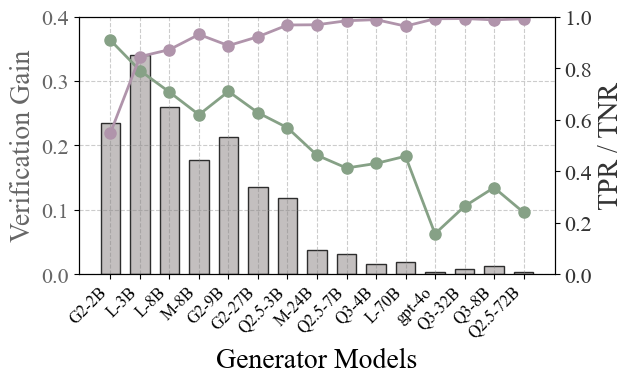

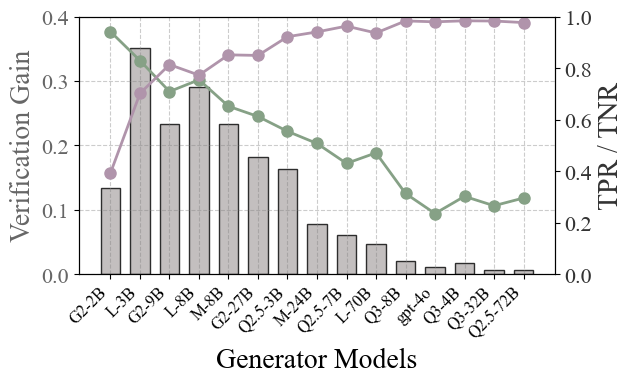

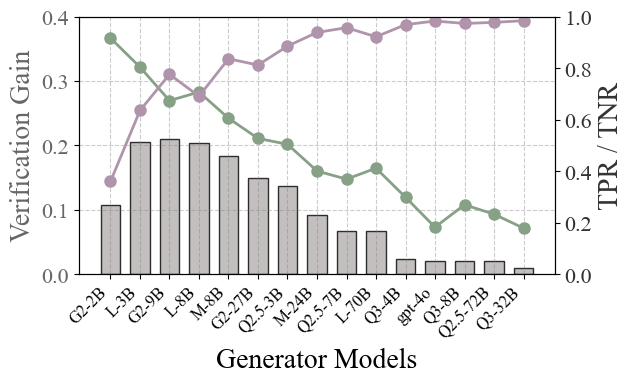

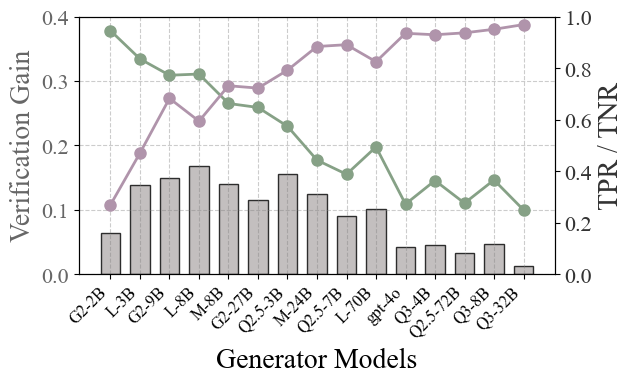

In [ ]:
verifier = 'gpt-4o'
bin_model_key = 'mean'
bin_src_folder='results_correct'
mean_value = np.load(f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1/bin_generator_diff_lst_binmodel_{bin_model_key}.npy', allow_pickle=True).item()

gen_src_path = f'{bin_src_folder}/subsample_rejectall_dice_verifier_{verifier}_w_dataindex_label_meandiff_bins_{bin_model_key}_v1'
considered_model_lst = [
    'google/gemma-2-2b-it',
    'meta-llama/Llama-3.2-3B-Instruct', 
    'meta-llama/Llama-3.1-8B-Instruct',
    'google/gemma-2-9b-it',
    'mistralai/Ministral-8B-Instruct-2410',  
    'google/gemma-2-27b-it',
    'Qwen/Qwen2.5-3B-Instruct', 
    'Qwen/Qwen2.5-7B-Instruct',
    'Qwen/Qwen2.5-72B-Instruct',
    'mistralai/Mistral-Small-24B-Instruct-2501', 
    'meta-llama/Llama-3.3-70B-Instruct',
    'Qwen/Qwen3-4B', 
    'Qwen/Qwen3-8B', 
    'Qwen/Qwen3-32B',
    'gpt-4o',
]
    # 'Qwen/Qwen2.5-14B-Instruct',
    # 'Qwen/Qwen2.5-32B-Instruct',

# Collect data for each model

for bins in [
            '[0.7,0.8)',
            '[0.6,0.7)',
            '[0.5,0.6)',
             '[0.4,0.5)',
             ]:
    all_data = {'original':[], 
                'tnr':[], 'tpr': [], 
                'tnr_agg':[],  
                'tpr_agg': []}
    model_names = []

    model_means = []
    for model_key in considered_model_lst:
        #print('mean_value[bins][model_key]',bins, model_key,  mean_value[bins][model_key])
        mean_val = np.mean(mean_value[bins][model_key])
        model_means.append((model_key, mean_val))
        
    model_means_sorted = sorted(model_means, key=lambda x: x[1])
    #for key, value in model_means_sorted:
    #    print(key, value)
    # Extract just the model names as a list
    model_lst = [model_key for model_key, mean_val in model_means_sorted if model_key in considered_model_lst]

    for model in model_lst:
        try:
            # Convert model name to filename format (replace / with _)
            model_filename = model.replace('/', '_').replace('-', '_')
            
            # Load the gene_score file for this model
            gene_score = np.load(f"{gen_src_path}/gene_score_{model_filename}.npy", 
                            allow_pickle=True).item()
            
            # Extract the average scores for the [0.8,0.9) bin
            if bins in gene_score:
                # Extract scores and filter out NaN values
                #scores = [item['average'] - item['average_original'] for item in gene_score[bins]]
                #scores_filtered = scores #[s for s in scores if not np.isnan(s)]
                scores_filtered = []
                scores_tnr_avg = []
                scores_tpr_avg = []
                tnr_agg = 0
                false_agg = 0
                tpr_agg = 0
                true_agg = 0
                for item in gene_score[bins]:
                    if not np.isnan(item['average']) and not np.isnan(item['average_original']):
                        improv = item['average'] - item['average_original']
                        scores_filtered.append(improv)
                    
                    if item['false_count'] > 0:
                        scores_tnr_avg.append(item['true_neg_pred_half'] / item['false_count'])
                        
                    tnr_agg += item['true_neg_pred_half']
                    false_agg += item['false_count']
                    
                    if item['true_count'] > 0:
                        scores_tpr_avg.append(item['true_pos_pred_half'] / item['true_count'])
                    
                    tpr_agg += item['true_pos_pred_half']
                    true_agg += item['true_count']
                # after_scores = [item['average'] for item in gene_score[bins]]
                # after_scores_filtered = [s for s in after_scores if not np.isnan(s)]
                
                #length = len(scores)
                
                if scores_filtered:  # Only add if we have non-NaN values
                    #print('scores_filtered', scores_filtered)
                    all_data['original'].append(scores_filtered)
                    all_data['tnr'].append(scores_tnr_avg)
                    #all_data['tnr_agg'].append(tnr_agg / false_agg)
                    all_data['tpr'].append(scores_tpr_avg)
                    #all_data['tpr_agg'].append(tpr_agg / true_agg)
                    
                    
                    #all_data['after_filter'].append(after_scores_filtered)
                    model_names.append(convert_model_name(model))  # Use just the model name part
                    #print(f"{model}: {len(scores)} total samples, {len(scores_filtered)} valid samples, {len(scores) - len(scores_filtered)} NaN values filtered")
                else:
                    print(f"All scores are NaN for {model}")
            else:
                print(f"No [0.8,0.9) bin found for {model}")
                
        except FileNotFoundError:
            print(f"File not found for model: {model}")
        except Exception as e:
            print(f"Error loading {model}: {e}")

    # Check if we have any valid data
    if not all_data['original']:
        print("No valid data found for any models!")
    else:
        # Create the box plot
        
        n_models = len(all_data['original'])
    
        # Create positions for boxes
        positions_original = np.arange(1, n_models * 3, 3)  # 1, 4, 7, 10, ...
        #positions_after = np.arange(1, n_models * 3, 3)    # 2, 5, 8, 11, ...
        
        #plt.figure(figsize=(6, 4))
        fig, ax1 = plt.subplots(figsize=(6.5, 4))
        positions = np.arange(n_models)
        # Create box plots for original data
       # print(np.array(all_data['original']).shape)
        bar_width = 2
        bars = ax1.bar(positions_original, 
                    [np.mean(item) for item in all_data['original']],
                    bar_width,
                    label='Verification Gain',
                    color="#b4b0b0",
                    alpha=0.8,
                    edgecolor='black',
                    linewidth=1)

        # Set left y-axis properties
        ax1.set_xlabel('Generator Models', fontsize=20)
        ax1.set_ylabel('Verification Gain', fontsize=20, color='#666666')
        ax1.set_ylim([0, 0.4])  # Set limit for bar plot
        ax1.tick_params(axis='y', labelcolor='#666666', labelsize=16)
        ax1.set_xticks(positions_original)
        ax1.set_xticklabels(model_names, rotation=45, ha='right')

        # Create second y-axis for line plots
        ax2 = ax1.twinx()

        # Plot TNR and TPR on right y-axis
        line1 = ax2.plot(positions_original, 
                        [np.mean(item) for item in all_data['tnr']], 
                        marker='o', color="#86a186",
                        linewidth=2, markersize=8,
                        label='TNR')

        line2 = ax2.plot(positions_original, 
                        [np.mean(item) for item in all_data['tpr']], 
                        marker='o', color="#b094ab",
                        linewidth=2, markersize=8,
                        label='TPR')

        # Set right y-axis properties
        ax2.set_ylabel('TPR / TNR', fontsize=20, color='#333333')
        
        ax2.set_ylim([0, 1])  # Set limit for line plots
        ax2.tick_params(axis='y', labelcolor='#333333', labelsize=16)

        ax1.grid(True, linestyle='--', which='major', color='grey', alpha=.4)

        # Create combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        plt.tight_layout()

        # Save
        save_path = f'figures_draft/tts_subsample_reject_dice/improve_tpr_tnr_dual_axis_{bins}_wo_title.pdf'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')


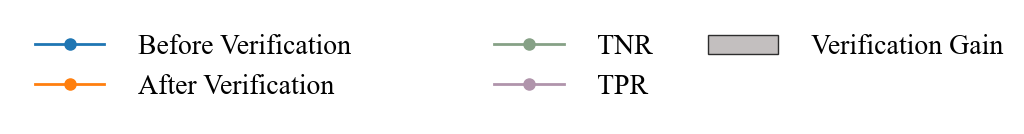

In [262]:
# CREATE COMBINED LEGEND - Left and Right Sections
fig_legend = plt.figure(figsize=(10, 1.5))
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Left side elements (Before/After)
left_elements = [
    Line2D([0], [0], color='#1f76b3', marker='o', 
           linewidth=2, markersize=8, markerfacecolor='#1f76b3'),
    Line2D([0], [0], color='#ff7f0e', marker='o', 
           linewidth=2, markersize=8, markerfacecolor='#ff7f0e')
]

# Right side elements (TNR, TPR, Verification)
right_elements = [
    Line2D([0], [0], color='#86a186', marker='o', 
           linewidth=2, markersize=8, markerfacecolor='#86a186'),
    Line2D([0], [0], color='#b094ab', marker='o', 
           linewidth=2, markersize=8, markerfacecolor='#b094ab'),
    Rectangle((0, 0), 1, 1, fc="#b4b0b0", alpha=0.8, 
              edgecolor='black', linewidth=1)
]

# Create left legend (Before/After in 2 rows)
legend1 = ax_legend.legend(left_elements, 
                          ['Before Verification', 'After Verification'],
                          loc='center left',
                          bbox_to_anchor=(0, 0.5),  # CHANGE THIS: smaller x = more left
                          ncol=1,
                          frameon=False,
                          fontsize=20,
                          handlelength=2.5,
                          handletextpad=1.2)

# Create right legend (TNR, TPR, Verification in 2 rows)
legend2 = ax_legend.legend(right_elements[:2] + [right_elements[2]],
                          ['TNR', 'TPR', 'Verification Gain'],
                          loc='center left',
                          bbox_to_anchor=(0.75, 0.5),  # CHANGE THIS: larger x = more right
                          ncol=2,
                          frameon=False,
                          fontsize=20,
                          handlelength=2.5,
                          handletextpad=1.2)
ax_legend.add_artist(legend1)

plt.tight_layout()
plt.savefig('figures_draft/tts/legend_combined_leftright.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
diff_range_lst = ['[0.9,1.0)', '[0.8,0.9)', '[0.7,0.8)', '[0.6,0.7)', '[0.5,0.6)', 
                  '[0.4,0.5)', '[0.3,0.4)', '[0.2,0.3)', '[0.1,0.2)', '(0.0,0.1)'][::-1]

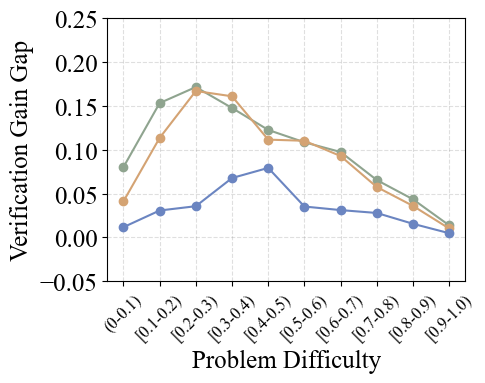

In [ ]:
generator_lst = [
#('google_gemma-2-2b-it', 'google_gemma_2_2b_it'),
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('Qwen_Qwen2.5-72B-Instruct', 'Qwen_Qwen2.5_72B_Instruct')
]
colors = [
    '#8FA48F',   # Muted green (was #7EB17E)
    '#D4A373',   # Muted orange (was #FF8C00)
    '#6B85C1'   # Muted blue (was #4169E1)
]

plt.figure(figsize=(5, 4))
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'

    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
        results_dict_lst.append(results_dict)


    mean_lst = [(np.nanmean(results_dict_lst[i]['delta']['improv_lst']), np.nanstd(results_dict_lst[i]['delta']['improv_lst'])) for i in range(len(results_dict_lst))]
    
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] 
    plt.plot(range(len([mean for mean, std in mean_lst])), [mean for mean, std in mean_lst], color=colors[g_i], marker='o')
    #plt.fill_between(range(len([mean for mean, std in mean_lst])), [mean-std for mean, std in mean_lst], [mean+std for mean, std in mean_lst], alpha=0.3)
    plt.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.xticks(range(len([mean for mean, std in mean_lst])), x_tick_labels, rotation=45, fontsize=12)
plt.yticks(fontsize=18)
plt.ylim([-0.05, 0.25])
plt.xlabel('Problem Difficulty', fontsize=18)
plt.ylabel('Verification Gain Gap', fontsize=18)
plt.tight_layout()
plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_improvement_w_yscale.pdf', dpi=300, bbox_inches='tight')

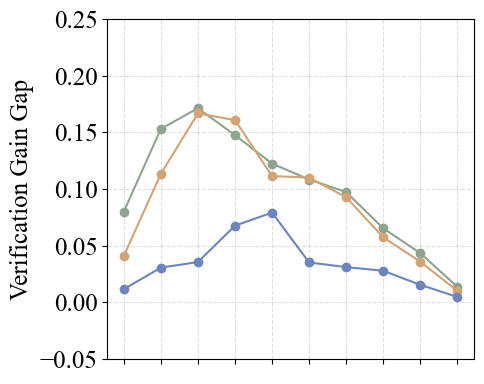

In [ ]:
diff_range_lst = ['[0.9,1.0)', '[0.8,0.9)', '[0.7,0.8)', '[0.6,0.7)', '[0.5,0.6)', 
                  '[0.4,0.5)', '[0.3,0.4)', '[0.2,0.3)', '[0.1,0.2)', '(0.0,0.1)'][::-1]

generator_lst = [
#('google_gemma-2-2b-it', 'google_gemma_2_2b_it'),
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('Qwen_Qwen2.5-72B-Instruct', 'Qwen_Qwen2.5_72B_Instruct')
]
colors = [
    '#8FA48F',   # Muted green (was #7EB17E)
    '#D4A373',   # Muted orange (was #FF8C00)
    '#6B85C1'   # Muted blue (was #4169E1)
]

plt.figure(figsize=(5, 4))
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'

    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
        results_dict_lst.append(results_dict)


    mean_lst = [(np.nanmean(results_dict_lst[i]['delta']['improv_lst']), np.nanstd(results_dict_lst[i]['delta']['improv_lst'])) for i in range(len(results_dict_lst))]
    
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] 
    plt.plot(range(len([mean for mean, std in mean_lst])), [mean for mean, std in mean_lst], color=colors[g_i], marker='o')
    #plt.fill_between(range(len([mean for mean, std in mean_lst])), [mean-std for mean, std in mean_lst], [mean+std for mean, std in mean_lst], alpha=0.3)
    plt.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.xticks(range(len([mean for mean, std in mean_lst])), ['' for _ in range(len([mean for mean, std in mean_lst]))])
plt.yticks(fontsize=18)
plt.ylim([-0.05, 0.25])
#plt.xlabel('Problem Difficulty', fontsize=18)
plt.ylabel('Verification Gain Gap', fontsize=18)
plt.tight_layout()
plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_improvement_w_yscale_wo_xticks.pdf', dpi=300, bbox_inches='tight')

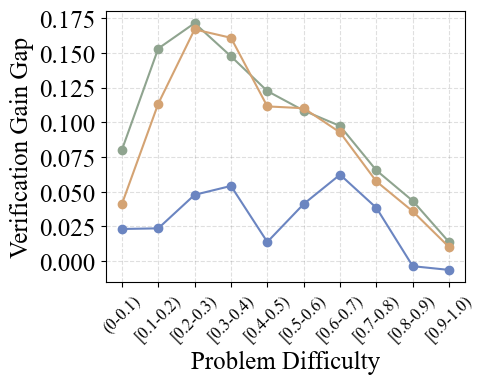

In [ ]:
generator_lst = [
#('google_gemma-2-2b-it', 'google_gemma_2_2b_it'),
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('meta-llama_Llama-3.3-70B-Instruct', 'meta_llama_Llama_3.3_70B_Instruct'),
]
colors = [
    '#8FA48F',   # Muted green (was #7EB17E)
    '#D4A373',   # Muted orange (was #FF8C00)
    '#6B85C1'   # Muted blue (was #4169E1)
]

plt.figure(figsize=(5, 4))
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'

    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
        results_dict_lst.append(results_dict)


    mean_lst = [(np.nanmean(results_dict_lst[i]['delta']['improv_lst']), np.nanstd(results_dict_lst[i]['delta']['improv_lst'])) for i in range(len(results_dict_lst))]
    
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] 
    plt.plot(range(len([mean for mean, std in mean_lst])), [mean for mean, std in mean_lst], color=colors[g_i], marker='o')
    #plt.fill_between(range(len([mean for mean, std in mean_lst])), [mean-std for mean, std in mean_lst], [mean+std for mean, std in mean_lst], alpha=0.3)
    plt.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

plt.xticks(range(len([mean for mean, std in mean_lst])), x_tick_labels, rotation=45, fontsize=12)
plt.yticks(fontsize=18)

plt.xlabel('Problem Difficulty', fontsize=18)
plt.ylabel('Verification Gain Gap', fontsize=18)
plt.tight_layout()
plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_improvement_w_llama3_70b.pdf', dpi=300, bbox_inches='tight')

In [1]:
diff_range_lst = ['[0.9,1.0)', '[0.8,0.9)', '[0.7,0.8)', '[0.6,0.7)', '[0.5,0.6)', 
                  '[0.4,0.5)', '[0.3,0.4)', '[0.2,0.3)', '[0.1,0.2)', '(0.0,0.1)'][::-1]

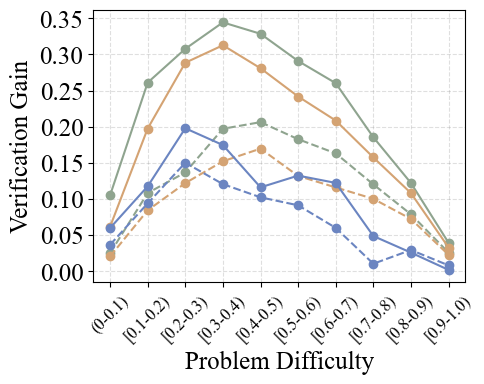

In [ ]:
generator_lst = [
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('meta-llama_Llama-3.3-70B-Instruct', 'meta_llama_Llama_3.3_70B_Instruct'),
]
colors = [
    '#8FA48F',   # Muted green (was #7EB17E)
    '#D4A373',   # Muted orange (was #FF8C00)
    '#6B85C1'   # Muted blue (was #4169E1)
]

plt.figure(figsize=(5, 4))
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'
    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
        results_dict_lst.append(results_dict)


    gpt_mean_lst = [(np.nanmean(results_dict_lst[i]['gpt']['improv_lst']), np.nanstd(results_dict_lst[i]['gpt']['improv_lst'])) 
                    for i in range(len(results_dict_lst))]
    qwen_mean_lst = [(np.nanmean(results_dict_lst[i]['qwen']['improv_lst']), np.nanstd(results_dict_lst[i]['qwen']['improv_lst'])) 
                    for i in range(len(results_dict_lst))]
    
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] 
    plt.plot(range(len([mean for mean, std in gpt_mean_lst])), [mean for mean, std in gpt_mean_lst], '-' , 
                                color=colors[g_i], marker='o')
    plt.plot(range(len([mean for mean, std in qwen_mean_lst])), [mean for mean, std in qwen_mean_lst], '--' , 
                                color=colors[g_i], marker='o')
    #plt.fill_between(range(len([mean for mean, std in mean_lst])), [mean-std for mean, std in mean_lst], [mean+std for mean, std in mean_lst], alpha=0.3)
    plt.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
    
    #if g_i == 0:
    #    plt.legend()

plt.xticks(range(len([mean for mean, std in mean_lst])), x_tick_labels, rotation=45, fontsize=12)
plt.yticks(fontsize=18)

plt.xlabel('Problem Difficulty', fontsize=18)
plt.ylabel('Verification Gain', fontsize=18)
plt.tight_layout()
plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_gain_comparison_w_llama3_70b.pdf', dpi=300, bbox_inches='tight')

In [ ]:
generator_lst = [
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('Qwen_Qwen2.5-72B-Instruct', 'Qwen_Qwen2.5_72B_Instruct')
]
color_maps = [
     "#7EB17E",  # Muted sage green
    "#8E1B8E",  # Muted mauve/purple
   "#9C3030"   # Dark gray
]
all_results = {} 
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'

    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0,
            'true_pos_half_agg_rate':[],
            'true_neg_half_agg_rate':[],
            'balanced_acc': []
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0,
            'true_pos_half_agg_rate':[],
            'true_neg_half_agg_rate':[],
            'balanced_acc': []
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
                if item_gpt['true_count'] > 0:
                    results_dict['gpt']['true_pos_half_agg_rate'].append(item_gpt['true_pos_pred_half'] / item_gpt['true_count'])
                
                if item_gpt['false_count'] > 0:
                    results_dict['gpt']['true_neg_half_agg_rate'].append(item_gpt['true_neg_pred_half'] / item_gpt['false_count'])

                if item_qwen['true_count'] > 0:
                    results_dict['qwen']['true_pos_half_agg_rate'].append(item_qwen['true_pos_pred_half'] / item_qwen['true_count'])
                
                if item_qwen['false_count'] > 0:
                    results_dict['qwen']['true_neg_half_agg_rate'].append(item_qwen['true_neg_pred_half'] / item_qwen['false_count'])
                
                if item_qwen['true_count'] > 0 and item_qwen['false_count'] > 0:
                    results_dict['qwen']['balanced_acc'].append( 0.5 * ((item_qwen['true_neg_pred_half'] / item_qwen['false_count']) + (item_qwen['true_pos_pred_half'] / item_qwen['true_count'])) )
                
                if item_gpt['true_count'] > 0 and item_gpt['false_count'] > 0:
                    results_dict['gpt']['balanced_acc'].append( 0.5 * ((item_gpt['true_neg_pred_half'] / item_gpt['false_count']) + (item_gpt['true_pos_pred_half'] / item_gpt['true_count'])) )
                    
        results_dict_lst.append(results_dict)

    all_results[g_i] = results_dict_lst


gpt_rates [0.3746527777777778, 0.5400096645467016, 0.6424009767349735, 0.741466091706775, 0.7589729629574897, 0.8721323218772558, 0.9306274287277532, 0.9274655097407748, 0.9551046414745846, 0.9813586638036084] qwen_rates [0.48572048611111107, 0.6304439901662123, 0.6668312417934634, 0.7689559077913115, 0.7818343335294177, 0.8388494466672867, 0.8816585167922079, 0.9093187702229432, 0.9269779240162956, 0.9622459489210504]
gpt_rates [0.3385987815491732, 0.5749721706864565, 0.6063544807912986, 0.7784672857498944, 0.8251913001393418, 0.8660055160232191, 0.9136310265436755, 0.9385346429215133, 0.9434049744881402, 0.9842902338096378] qwen_rates [0.48996953872932986, 0.6668221758400329, 0.6712567452342586, 0.7726211332733072, 0.8131773521131578, 0.8113450641758024, 0.8987874333918009, 0.9017803361684693, 0.9265442583506734, 0.9662581896825344]
gpt_rates [0.5542067307692308, 0.7460017559415151, 0.7688258975312484, 0.8342233067139899, 0.8517441313144021, 0.8547212829914068, 0.898640841207489, 0.9

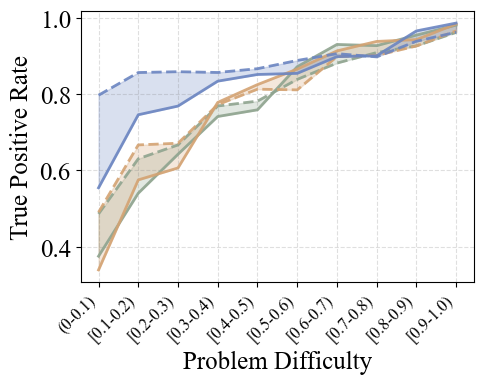

gpt_rates [0.8640539571084784, 0.8397726024661551, 0.8158213996335703, 0.786153759548845, 0.8072121328971752, 0.7765346995642562, 0.8046212887213898, 0.8050957464206286, 0.8545208426049549, 0.8674300254452926] qwen_rates [0.6675767912127473, 0.6533932315268517, 0.644198518415927, 0.6251121601660454, 0.6369125132098192, 0.6069453897482063, 0.6034177248434075, 0.5798525017753127, 0.5858923008455718, 0.6157760814249363]
gpt_rates [0.830332088510349, 0.7672608129944276, 0.781364020290428, 0.7415377475998577, 0.7028008740368199, 0.6810129641400497, 0.6922238848108413, 0.69744345440501, 0.7659966576633244, 0.7947072072072072] qwen_rates [0.6393829716887051, 0.5876613059136291, 0.5942539876430094, 0.5575280308547466, 0.5721012245535628, 0.5127712591236631, 0.4649270709162013, 0.5167284956611023, 0.5444762028095361, 0.5717342342342342]
gpt_rates [0.45979259826627616, 0.3671316071191641, 0.37778371799472504, 0.32279090247731357, 0.3589608315045858, 0.32399402976467767, 0.2663368885542798, 0.328

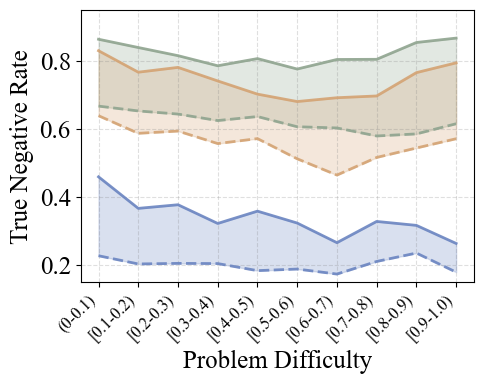

gpt_rates [0.6193533674431281, 0.6898911335064283, 0.7291111881842719, 0.76380992562781, 0.7830925479273325, 0.8243335107207559, 0.8676243587245713, 0.8662806280807017, 0.9048127420397695, 0.9243943446244505] qwen_rates [0.5766486386619292, 0.6419186108465321, 0.6555148801046952, 0.6970340339786786, 0.7093734233696184, 0.7228974182077466, 0.7425381208178078, 0.744585635999128, 0.7564351124309336, 0.7890110151729934]
gpt_rates [0.5844654350297612, 0.671116491840442, 0.6938592505408631, 0.7600025166748761, 0.7639960870880809, 0.7735092400816345, 0.8029274556772582, 0.8179890486632617, 0.8547008160757322, 0.8894987205084225] qwen_rates [0.5646762552090174, 0.6272417408768309, 0.632755366438634, 0.665074582064027, 0.6926392883333603, 0.6620581616497327, 0.6818572521540012, 0.7092544159147859, 0.7355102305801048, 0.7689962119583843]
gpt_rates [0.5069996645177535, 0.5565666815303396, 0.5733048077629868, 0.5785071045956518, 0.605352481409494, 0.5893576563780423, 0.5824888648808844, 0.61480764

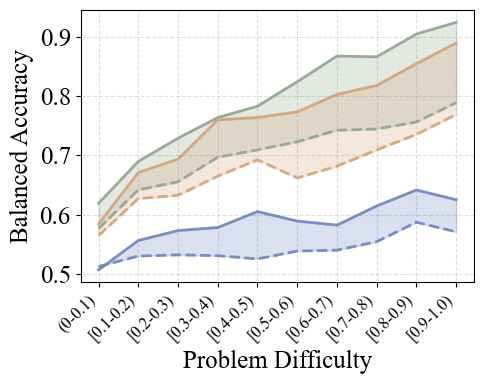

In [24]:
# Create two separate figures
for metric in ['TPR', 'TNR', 'balanced_acc']:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    
    x = np.arange(len(diff_range_lst))
    generators = ['3B', '8B', '72B']
    colors = [
        '#8FA48F',   # Muted green
        '#D4A373',   # Muted orange
        '#6B85C1'    # Muted blue
    ]
    
    for g_i in range(len(generator_lst)):
        results_dict_lst = all_results[g_i]
        
        if metric == 'TPR':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['true_pos_half_agg_rate']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['true_pos_half_agg_rate']) 
                         for i in range(len(results_dict_lst))]
        elif metric == 'TNR':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['true_neg_half_agg_rate']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['true_neg_half_agg_rate']) 
                         for i in range(len(results_dict_lst))]
        elif metric == 'balanced_acc':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['balanced_acc']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['balanced_acc']) 
                         for i in range(len(results_dict_lst))]
        
        # Plot lines
        ax.plot(x, gpt_rates, '-', color=colors[g_i], linewidth=2, 
                label=f'{generators[g_i]} (GPT-4o)', alpha=0.9)
        ax.plot(x, qwen_rates, '--', color=colors[g_i], linewidth=2,
                label=f'{generators[g_i]} (Qwen)', alpha=0.9)
        
        # Shade between them
        print('gpt_rates', gpt_rates, 'qwen_rates', qwen_rates)
        ax.fill_between(x, gpt_rates, qwen_rates, color=colors[g_i], alpha=0.25)
    
    # Set labels
    ax.set_xlabel('Problem Difficulty', fontsize=18)
    if metric == 'TPR':
        ax.set_ylabel(f'True Positive Rate', fontsize=18)
    elif metric == 'TNR':
        ax.set_ylabel(f'True Negative Rate', fontsize=18)
    elif metric == 'balanced_acc':
        ax.set_ylabel(f'Balanced Accuracy', fontsize=18)
    
    # Set x-ticks to show every two positions
    x_ticks_positions = x[::1]  # Every second position
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] #['0-10%', '20-30%', '40-50%', '60-70%', '80-90%']
    ax.set_xticks(x_ticks_positions)
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')
    
    
    # Add legend
    #ax.legend(loc='best', fontsize=9, ncol=2)
    ax.tick_params(axis='y', labelsize=18)
    # Grid
    ax.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
    
    plt.tight_layout()
    if metric == 'TNR':
        plt.ylim([0.15, 0.95])
    
    # Save each figure
    plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_yscale.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_yscale.png', dpi=300, bbox_inches='tight')
    
    plt.show()

gpt_rates [0.4127906976744186, 0.5479814692256784, 0.6450815620365793, 0.7442605445808863, 0.7602739726027398, 0.8724112426035503, 0.9306456160135326, 0.9276050080775444, 0.9556886227544911, 0.9814247295015323]
qwen_rates [0.502422480620155, 0.6320317670416943, 0.6643598615916955, 0.7720234917245061, 0.7829293993677555, 0.8387573964497042, 0.8814491119255708, 0.9100363489499192, 0.927459366980325, 0.9623803865157295]
gpt_rates [0.37512487512487513, 0.5792682926829268, 0.6080715059588299, 0.7832438878950507, 0.8256457564575646, 0.8662207357859532, 0.9146049481245012, 0.9389696451474989, 0.9437735257214555, 0.98451278659612]
qwen_rates [0.5074925074925075, 0.6722560975609756, 0.6757854821235103, 0.776386404293381, 0.8134225092250923, 0.8117968987534205, 0.8989092843841447, 0.902415562206071, 0.9265997490589711, 0.9665178571428571]
gpt_rates [0.599476439790576, 0.7503176620076238, 0.7738532110091743, 0.8356777493606138, 0.8502186588921283, 0.8554216867469879, 0.8988222698072805, 0.9027777

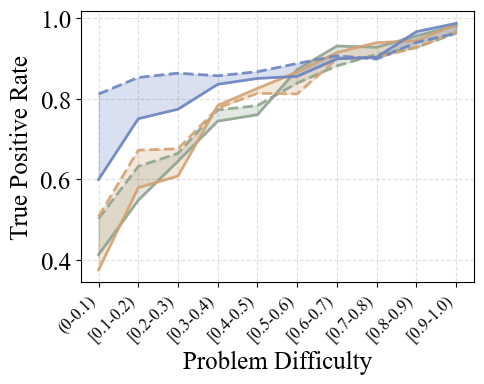

In [8]:
# Create two separate figures , 'TNR', 'balanced_acc'
for metric in ['TPR']:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    
    x = np.arange(len(diff_range_lst))
    generators = ['3B', '8B', '72B']
    colors = [
        '#8FA48F',   # Muted green
        '#D4A373',   # Muted orange
        '#6B85C1'    # Muted blue
    ]
    
    for g_i in range(len(generator_lst)):
        results_dict_lst = all_results[g_i]
        
        if metric == 'TPR':
            gpt_rates = [results_dict_lst[i]['gpt']['true_pos_half_agg'] / results_dict_lst[i]['gpt']['true_count_agg']  
                        for i in range(len(results_dict_lst))]
            qwen_rates = [results_dict_lst[i]['qwen']['true_pos_half_agg'] / results_dict_lst[i]['qwen']['true_count_agg']  
                        for i in range(len(results_dict_lst))]
        elif metric == 'TNR':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['true_neg_half_agg_rate']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['true_neg_half_agg_rate']) 
                         for i in range(len(results_dict_lst))]
        elif metric == 'balanced_acc':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['balanced_acc']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['balanced_acc']) 
                         for i in range(len(results_dict_lst))]
        
        # Plot lines
        ax.plot(x, gpt_rates, '-', color=colors[g_i], linewidth=2, 
                label=f'{generators[g_i]} (GPT-4o)', alpha=0.9)
        ax.plot(x, qwen_rates, '--', color=colors[g_i], linewidth=2,
                label=f'{generators[g_i]} (Qwen)', alpha=0.9)
        
        # Shade between them
        print('gpt_rates', gpt_rates)
        print('qwen_rates', qwen_rates)
        ax.fill_between(x, gpt_rates, qwen_rates, color=colors[g_i], alpha=0.25)
    
    # Set labels
    ax.set_xlabel('Problem Difficulty', fontsize=18)
    if metric == 'TPR':
        ax.set_ylabel(f'True Positive Rate', fontsize=18)
    elif metric == 'TNR':
        ax.set_ylabel(f'True Negative Rate', fontsize=18)
    elif metric == 'balanced_acc':
        ax.set_ylabel(f'Balanced Accuracy', fontsize=18)
    
    # Set x-ticks to show every two positions
    x_ticks_positions = x[::1]  # Every second position
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] #['0-10%', '20-30%', '40-50%', '60-70%', '80-90%']
    ax.set_xticks(x_ticks_positions)
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')
    
    
    # Add legend
    #ax.legend(loc='best', fontsize=9, ncol=2)
    ax.tick_params(axis='y', labelsize=18)
    # Grid
    ax.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
    
    plt.tight_layout()
    if metric == 'TNR':
        plt.ylim([0.15, 0.95])
    
    # Save each figure
    #plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_yscale.pdf', dpi=300, bbox_inches='tight')
    #plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_yscale.png', dpi=300, bbox_inches='tight')
    
    plt.show()

In [ ]:
generator_lst = [
('meta-llama_Llama-3.2-3B-Instruct', 'meta_llama_Llama_3.2_3B_Instruct'),
('meta-llama_Llama-3.1-8B-Instruct', 'meta_llama_Llama_3.1_8B_Instruct'),
('meta-llama_Llama-3.3-70B-Instruct', 'meta_llama_Llama_3.3_70B_Instruct'),
]
color_maps = [
     "#7EB17E",  # Muted sage green
    "#8E1B8E",  # Muted mauve/purple
   "#9C3030"   # Dark gray
]
all_results = {} 
for g_i, generator in enumerate(generator_lst):
    verifier = 'gpt-4o'

    path = f"results_correct/subsample_rejectall_dice_verifier_gpt-4o_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_gpt4o = np.load(path, allow_pickle=True).item()

    path = f"results_correct/subsample_rejectall_dice_verifier_Qwen/Qwen2.5-7B-Instruct_w_dataindex_label_meandiff_bins_{generator[0]}_v1/gene_score_{generator[1]}.npy"
    dataframe_qwen= np.load(path, allow_pickle=True).item()


    results_dict_lst =[]
    for range_key in diff_range_lst:
        results_dict = {'gpt':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0,
            'true_pos_half_agg_rate':[],
            'true_neg_half_agg_rate':[],
            'balanced_acc': []
            },
            'qwen':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0,
            'true_pos_half_agg_rate':[],
            'true_neg_half_agg_rate':[],
            'balanced_acc': []
            },
            'delta':{
            'improv_lst':[],
            'true_pos_half_agg':0,
            'true_neg_half_agg':0,
            'true_count_agg':0,
            'false_count_agg':0
            },          
        }
        #print(len(dataframe_gpt4o[range_key]), len(dataframe_qwen[range_key]))
        for item_gpt, item_qwen in zip(dataframe_gpt4o[range_key], dataframe_qwen[range_key]):
            if not np.isnan(item_gpt['average']) and not np.isnan(item_qwen['average']):
                gpt_improv = item_gpt['average'] - item_gpt['average_original']
                qwen_improve = item_qwen['average'] - item_qwen['average_original']
                
                results_dict['gpt']['improv_lst'].append(gpt_improv)
                results_dict['qwen']['improv_lst'].append(qwen_improve)
                results_dict['delta']['improv_lst'].append(gpt_improv - qwen_improve)
                
                results_dict['gpt']['true_pos_half_agg'] += item_gpt['true_pos_pred_half']
                results_dict['gpt']['true_neg_half_agg'] += item_gpt['true_neg_pred_half']
                results_dict['gpt']['true_count_agg'] += item_gpt['true_count']
                results_dict['gpt']['false_count_agg'] += item_gpt['false_count']
                
                results_dict['qwen']['true_pos_half_agg'] += item_qwen['true_pos_pred_half']
                results_dict['qwen']['true_neg_half_agg'] += item_qwen['true_neg_pred_half']
                results_dict['qwen']['true_count_agg'] += item_qwen['true_count']
                results_dict['qwen']['false_count_agg'] += item_qwen['false_count']
                
                if item_gpt['true_count'] > 0:
                    results_dict['gpt']['true_pos_half_agg_rate'].append(item_gpt['true_pos_pred_half'] / item_gpt['true_count'])
                
                if item_gpt['false_count'] > 0:
                    results_dict['gpt']['true_neg_half_agg_rate'].append(item_gpt['true_neg_pred_half'] / item_gpt['false_count'])

                if item_qwen['true_count'] > 0:
                    results_dict['qwen']['true_pos_half_agg_rate'].append(item_qwen['true_pos_pred_half'] / item_qwen['true_count'])
                
                if item_qwen['false_count'] > 0:
                    results_dict['qwen']['true_neg_half_agg_rate'].append(item_qwen['true_neg_pred_half'] / item_qwen['false_count'])
                
                if item_qwen['true_count'] > 0 and item_qwen['false_count'] > 0:
                    results_dict['qwen']['balanced_acc'].append( 0.5 * ((item_qwen['true_neg_pred_half'] / item_qwen['false_count']) + (item_qwen['true_pos_pred_half'] / item_qwen['true_count'])) )
                
                if item_gpt['true_count'] > 0 and item_gpt['false_count'] > 0:
                    results_dict['gpt']['balanced_acc'].append( 0.5 * ((item_gpt['true_neg_pred_half'] / item_gpt['false_count']) + (item_gpt['true_pos_pred_half'] / item_gpt['true_count'])) )
                    
        results_dict_lst.append(results_dict)

    all_results[g_i] = results_dict_lst


gpt_rates [0.3746527777777778, 0.5400096645467016, 0.6424009767349735, 0.741466091706775, 0.7589729629574897, 0.8721323218772558, 0.9306274287277532, 0.9274655097407748, 0.9551046414745846, 0.9813586638036084] qwen_rates [0.48572048611111107, 0.6304439901662123, 0.6668312417934634, 0.7689559077913115, 0.7818343335294177, 0.8388494466672867, 0.8816585167922079, 0.9093187702229432, 0.9269779240162956, 0.9622459489210504]
gpt_rates [0.3385987815491732, 0.5749721706864565, 0.6063544807912986, 0.7784672857498944, 0.8251913001393418, 0.8660055160232191, 0.9136310265436755, 0.9385346429215133, 0.9434049744881402, 0.9842902338096378] qwen_rates [0.48996953872932986, 0.6668221758400329, 0.6712567452342586, 0.7726211332733072, 0.8131773521131578, 0.8113450641758024, 0.8987874333918009, 0.9017803361684693, 0.9265442583506734, 0.9662581896825344]
gpt_rates [0.4747286821705426, 0.6255122655122655, 0.64463162443291, 0.7035470085470086, 0.7076397176099462, 0.7287189314427067, 0.9048521153852974, 0.77

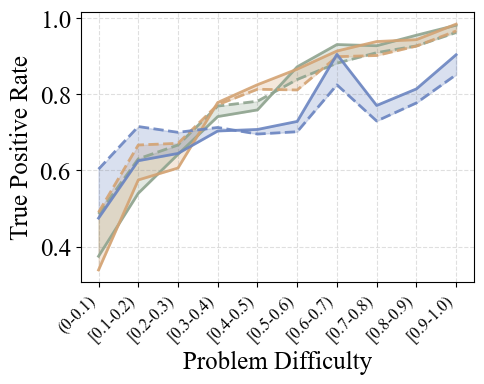

gpt_rates [0.8640539571084784, 0.8397726024661551, 0.8158213996335703, 0.786153759548845, 0.8072121328971752, 0.7765346995642562, 0.8046212887213898, 0.8050957464206286, 0.8545208426049549, 0.8674300254452926] qwen_rates [0.6675767912127473, 0.6533932315268517, 0.644198518415927, 0.6251121601660454, 0.6369125132098192, 0.6069453897482063, 0.6034177248434075, 0.5798525017753127, 0.5858923008455718, 0.6157760814249363]
gpt_rates [0.830332088510349, 0.7672608129944276, 0.781364020290428, 0.7415377475998577, 0.7028008740368199, 0.6810129641400497, 0.6922238848108413, 0.69744345440501, 0.7659966576633244, 0.7947072072072072] qwen_rates [0.6393829716887051, 0.5876613059136291, 0.5942539876430094, 0.5575280308547466, 0.5721012245535628, 0.5127712591236631, 0.4649270709162013, 0.5167284956611023, 0.5444762028095361, 0.5717342342342342]
gpt_rates [0.681144327765204, 0.5747126768388354, 0.6456835786104922, 0.6013006065326193, 0.5014755107679894, 0.5748454991703891, 0.4501912917999874, 0.48639203

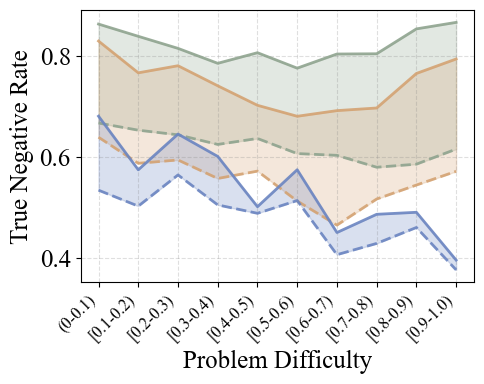

gpt_rates [0.6193533674431281, 0.6898911335064283, 0.7291111881842719, 0.76380992562781, 0.7830925479273325, 0.8243335107207559, 0.8676243587245713, 0.8662806280807017, 0.9048127420397695, 0.9243943446244505] qwen_rates [0.5766486386619292, 0.6419186108465321, 0.6555148801046952, 0.6970340339786786, 0.7093734233696184, 0.7228974182077466, 0.7425381208178078, 0.744585635999128, 0.7564351124309336, 0.7890110151729934]
gpt_rates [0.5844654350297612, 0.671116491840442, 0.6938592505408631, 0.7600025166748761, 0.7639960870880809, 0.7735092400816345, 0.8029274556772582, 0.8179890486632617, 0.8547008160757322, 0.8894987205084225] qwen_rates [0.5646762552090174, 0.6272417408768309, 0.632755366438634, 0.665074582064027, 0.6926392883333603, 0.6620581616497327, 0.6818572521540012, 0.7092544159147859, 0.7355102305801048, 0.7689962119583843]
gpt_rates [0.5779365049678734, 0.6001124711755504, 0.645157601521701, 0.652423807539814, 0.6045576141889676, 0.6517822153065479, 0.6775217035926424, 0.628497097

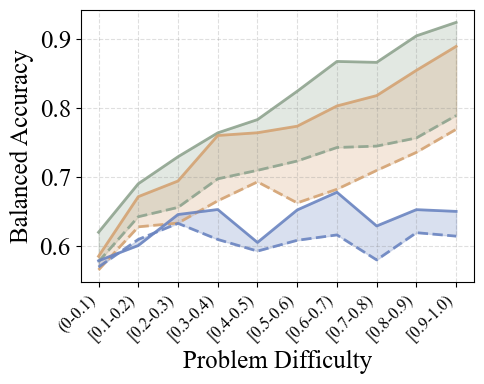

In [16]:
# Create two separate figures
for metric in ['TPR', 'TNR', 'balanced_acc']:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    
    x = np.arange(len(diff_range_lst))
    generators = ['3B', '8B', '72B']
    colors = [
        '#8FA48F',   # Muted green
        '#D4A373',   # Muted orange
        '#6B85C1'    # Muted blue
    ]
    
    for g_i in range(len(generator_lst)):
        results_dict_lst = all_results[g_i]
        
        if metric == 'TPR':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['true_pos_half_agg_rate']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['true_pos_half_agg_rate']) 
                         for i in range(len(results_dict_lst))]
        elif metric == 'TNR':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['true_neg_half_agg_rate']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['true_neg_half_agg_rate']) 
                         for i in range(len(results_dict_lst))]
        elif metric == 'balanced_acc':
            gpt_rates = [np.mean(results_dict_lst[i]['gpt']['balanced_acc']) 
                        for i in range(len(results_dict_lst))]
            qwen_rates = [np.mean(results_dict_lst[i]['qwen']['balanced_acc']) 
                         for i in range(len(results_dict_lst))]
        
        # Plot lines
        ax.plot(x, gpt_rates, '-', color=colors[g_i], linewidth=2, 
                label=f'{generators[g_i]} (GPT-4o)', alpha=0.9)
        ax.plot(x, qwen_rates, '--', color=colors[g_i], linewidth=2,
                label=f'{generators[g_i]} (Qwen)', alpha=0.9)
        
        # Shade between them
        print('gpt_rates', gpt_rates, 'qwen_rates', qwen_rates)
        ax.fill_between(x, gpt_rates, qwen_rates, color=colors[g_i], alpha=0.25)
    
    # Set labels
    ax.set_xlabel('Problem Difficulty', fontsize=18)
    if metric == 'TPR':
        ax.set_ylabel(f'True Positive Rate', fontsize=18)
    elif metric == 'TNR':
        ax.set_ylabel(f'True Negative Rate', fontsize=18)
    elif metric == 'balanced_acc':
        ax.set_ylabel(f'Balanced Accuracy', fontsize=18)
    
    # Set x-ticks to show every two positions
    x_ticks_positions = x[::1]  # Every second position
    x_tick_labels = ['(0-0.1)', '[0.1-0.2)', '[0.2-0.3)', '[0.3-0.4)', '[0.4-0.5)',
                        '[0.5-0.6)', '[0.6-0.7)', '[0.7-0.8)', '[0.8-0.9)', '[0.9-1.0)'] #['0-10%', '20-30%', '40-50%', '60-70%', '80-90%']
    ax.set_xticks(x_ticks_positions)
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')
    
    
    # Add legend
    #ax.legend(loc='best', fontsize=9, ncol=2)
    ax.tick_params(axis='y', labelsize=18)
    # Grid
    ax.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
    
    plt.tight_layout()
    
    # Save each figure
    plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_llama3_70b.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'figures_draft/tts_subsample_reject_dice/verifier_comparison_{metric}_w_llama3_70b.png', dpi=300, bbox_inches='tight')
    
    plt.show()

/fsx/home/yefan.zhou/tmp/ipykernel_4098729/6014579.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


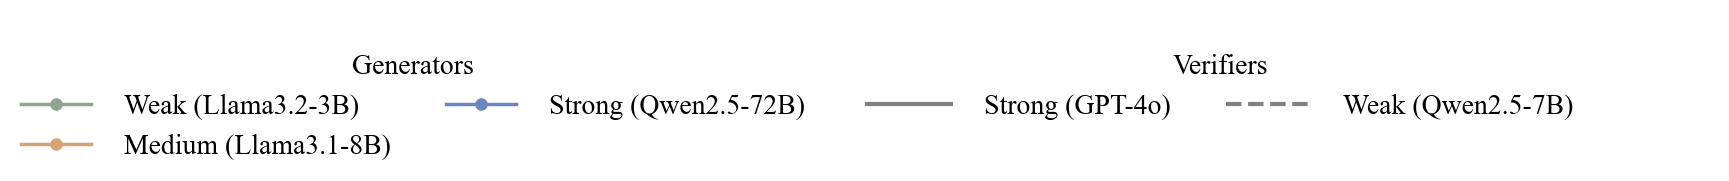

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create figure with two subplots for separate legends
fig = plt.figure(figsize=(12, 0.5))

# First subplot for Generators (needs more height for 2 rows)
ax1 = fig.add_subplot(121)
ax1.axis('off')

# Generator colors
colors = [
    '#8FA48F',   # Muted green
    '#D4A373',   # Muted orange
    '#6B85C1'    # Muted blue
]

# Generator legend elements
generator_elements = [
    Line2D([0], [0], color=colors[0], linewidth=2.5, marker='o', markersize=8),
    Line2D([0], [0], color=colors[1], linewidth=2.5, marker='o', markersize=8),
    Line2D([0], [0], color=colors[2], linewidth=2.5, marker='o', markersize=8)
]

generator_labels = ['Weak (Llama3.2-3B)', 'Medium (Llama3.1-8B)', 'Strong (Qwen2.5-72B)']

# Create first legend with 2 columns to force 2 rows
legend1 = ax1.legend(generator_elements, generator_labels,
                     bbox_to_anchor=(0.1, 0.5),  # Position in axes coordinates
           
                     ncol=2,  # 2 columns will create 2 rows for 3 items
                     frameon=False,
                     fontsize=20,
                     columnspacing=2,
                     handlelength=2.5,
                     title='Generators',
                     title_fontsize=22,
                     handletextpad=1.2,
                     labelspacing=0.5)

# Second subplot for Verifiers
ax2 = fig.add_subplot(122)
ax2.axis('off')

# Verifier legend elements
verifier_elements = [
    Line2D([0], [0], color='gray', linestyle='-', linewidth=3),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=3)
]

verifier_labels = ['Strong (GPT-4o)', 'Weak (Qwen2.5-7B)']

# Create second legend
legend2 = ax2.legend(verifier_elements, verifier_labels,
                     bbox_to_anchor=(0.7, 0.5),  # Position in axes coordinates
              
                     ncol=2,  # Both in one row
                     frameon=False,
                     fontsize=20,
                     columnspacing=2,
                     handlelength=3,
                     title='Verifiers',
                     title_fontsize=22,
                     handletextpad=1.2)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.savefig('figures_draft/tts_subsample/legend_two_separate.pdf', dpi=300, bbox_inches='tight')
plt.show()